## OXFORD-IIIT PET BREED CLASSIFICATION - ASSIGNMENT 1

In this assignment, we will classify photographs of **37 cat and dog breeds** from the Oxford-IIIT Pet dataset. A much harder problem than Fashion-MNIST (assignment 0), on real colour photographs of varying size, with roughly 100 training images per class. Along the way we will build the three things that make computer vision work in practice: convolutions, data augmentation, and transfer learning.

The assignment has four problems:

* **Problem 1 -- What a convolution actually does.** No training at all. We look at one convolution, count its parameters, work out how much of the image a single unit can see, and then run the permutation experiment that Assignment 0 promised. By the end you should be able to say precisely what a convolutional layer assumes about images, and what it buys you in exchange.
* **Problem 2 -- The data, and a CNN trained from scratch.** An exploratory analysis of real photographs (which looks very different from the Fashion-MNIST one), an input pipeline, and a small CNN trained from scratch. It will not work very well. Understanding *why* is the point.
* **Problem 3 -- Data augmentation.** We invent new training images out of the ones we have. This is not free data, and the choice of which transformations to use is a statement about the problem, not a technical detail.
* **Problem 4 -- Transfer learning.** We take a network someone else trained on a million ImageNet photographs and reuse it. It will beat everything above by a wide margin while training *fewer* parameters. We then have to be careful about what our final number actually means.

**How this assignment is evaluated.** Most of the code is written for you. What you produce is:

1. A choice in each `YOUR DECISION` block, and a one-sentence justification in the comment.
2. A written answer to each **Question**. Use your own wording, and keep it short: the reasoning is what is marked, and a longer answer is not a better one.

The aim of this assignment is not to fail anyone, but to learn. Often there is not an unique correct answer, but you only have to express a reasoning. Writing a "wrong" reasoning will not make you fail the assignment, but can only lead to a constructive discussion. It is better to make mistakes in the assignments, than during the oral examination.

**Practical notes.**

- Everything is PyTorch, as in Assignment 0. `torchvision` downloads the dataset for you on the first run (about 800 MB); after that it is read from disk.
- Use a **GPU runtime**. It is recommended to use Kaggle or Google Colab, both services offer free GPU usage, and the monthly limit is way above what this course requires.
- **The numbers quoted in the questions assume `IMG_SIZE = 224`.** Several questions cite a concrete figure -- a 46x46 receptive field, a 14x14 final feature map, accuracies in the high 80s. Those all follow from 224. If you are forced onto a smaller input, your printouts will differ and *your printouts are the ones that count*: answer from what your own run produced, and say which size you used.
- Several cells ask you to **write down a prediction before you run them**. Do that. Being wrong on paper is how you find out what you actually believe.

### 0 - Utilities provided for you

The cell below contains everything mechanical: imports, the device setup, plotting helpers, and the
training loop.

Read it now -- especially `train_model`, because several questions later on are about what it does --
but you will not need to modify any of it.

In [1]:
# Utilities provided for you. Read them, but you do not need to modify anything here.

import itertools
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, models, transforms
import torchvision.transforms.functional as TF

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)


def set_seed(seed=0):
    """Make a run reproducible (as far as CUDA allows)."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# ------------------------------------------------------------------ display helpers

# ImageNet channel statistics. We will discuss in Problem 2 why these particular
# numbers keep showing up, and in Problem 4 why we are eventually forced to use them.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def denormalize(x, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Undo transforms.Normalize so that a tensor can be displayed as an image."""
    m = torch.tensor(mean).view(-1, 1, 1)
    s = torch.tensor(std).view(-1, 1, 1)
    return (x.cpu() * s + m).clamp(0, 1)


def show_images(images, titles=None, ncols=6, figsize=None, cmap=None, denorm=False):
    """
    Plot a list of images in a grid.

    images -- list of PIL images, or (C, H, W) / (H, W) tensors
    titles -- optional list of per-image titles
    denorm -- set True if the tensors have been through transforms.Normalize
    """
    n = len(images)
    nrows = int(np.ceil(n / ncols))
    figsize = figsize or (2.1 * ncols, 2.4 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for ax, img in zip(axes, images):
        if torch.is_tensor(img):
            img = denormalize(img) if denorm else img.cpu()
            img = img.squeeze(0).numpy() if img.ndim == 3 and img.shape[0] == 1 else img
            img = img.permute(1, 2, 0).numpy() if torch.is_tensor(img) and img.ndim == 3 else np.asarray(img)
        ax.imshow(img, cmap=cmap)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    if titles is not None:
        for ax, t in zip(axes, titles):
            ax.set_title(t, fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_curves(histories, title="Training curves"):
    """
    Plot loss and accuracy curves.

    histories -- dict mapping a run name to the history dict returned by train_model()
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, h in histories.items():
        epochs = np.arange(1, len(h["loss"]) + 1)
        axes[0].plot(epochs, h["loss"], label=f"{name} (train)")
        if h.get("val_loss"):
            axes[0].plot(epochs, h["val_loss"], "--", label=f"{name} (val)")
        axes[1].plot(epochs, h["accuracy"], label=f"{name} (train)")
        if h.get("val_accuracy"):
            axes[1].plot(epochs, h["val_accuracy"], "--", label=f"{name} (val)")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy loss"); axes[0].set_title("Loss")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Accuracy")
    for ax in axes:
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, classes, title="Confusion matrix", cmap=plt.cm.YlGn, annotate=False):
    """Plot a confusion matrix normalized by row (i.e. by true class)."""
    plt.figure(figsize=(11, 11), dpi=110)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    plt.imshow(cm_norm, interpolation="nearest", cmap=cmap, vmin=0, vmax=1)
    plt.title(title, fontsize=11)
    plt.colorbar(fraction=0.046)
    ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, fontsize=7, rotation=45, ha="right")
    plt.yticks(ticks, classes, fontsize=7)
    if annotate:
        thresh = cm_norm.max() / 2.0
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            if cm[i, j]:
                plt.text(j, i, "%d" % cm[i, j], ha="center", va="center", fontsize=5,
                         color="white" if cm_norm[i, j] > thresh else "black")
    plt.ylabel("True Label", fontsize=9)
    plt.xlabel("Predicted Label", fontsize=9)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------ model inspection

def count_params(model):
    """Return (total, trainable) parameter counts."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def shape_trace(model, input_shape=(3, 224, 224)):
    """
    Push one dummy image through a nn.Sequential model and print, for every layer,
    the shape of what comes out and how many parameters that layer owns.
    """
    x = torch.zeros(1, *input_shape)
    rows = [("input", tuple(x.shape[1:]), 0)]
    for layer in model:
        x = layer(x)
        p = sum(q.numel() for q in layer.parameters())
        rows.append((layer.__class__.__name__, tuple(x.shape[1:]), p))

    w = max(len(r[0]) for r in rows) + 2
    print(f"{'layer':<{w}}{'output shape':>20}{'params':>14}")
    print("-" * (w + 34))
    for name, shape, p in rows:
        print(f"{name:<{w}}{str(shape):>20}{p:>14,}")
    print("-" * (w + 34))
    print(f"{'TOTAL':<{w}}{'':>20}{sum(r[2] for r in rows):>14,}")


def receptive_field(layers):
    """
    Compute the receptive field of one unit in the final feature map.

    layers -- list of (kernel_size, stride) pairs, in forward order

    Returns (receptive_field_in_pixels, jump_in_pixels_between_neighbouring_units).
    """
    r, j = 1, 1
    for k, s in layers:
        r = r + (k - 1) * j
        j = j * s
    return r, j


# ------------------------------------------------------------------ training and evaluation

def evaluate(model, loader, return_preds=False):
    """Run the model over a loader and return (accuracy, macro_f1) -- and optionally the predictions."""
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(device, non_blocking=True))
            preds.append(logits.argmax(dim=1).cpu())
            targets.append(y)
    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds, average="macro")
    return (acc, f1, preds, targets) if return_preds else (acc, f1)


def train_model(model, train_loader, val_loader, criterion, optimizer,
                epochs, scheduler=None, print_every=1,
                early_stopping_patience=None, monitor="val_accuracy",
                checkpoint_path=None):
    """
    Train a model, optionally with a learning-rate schedule, early stopping and checkpointing.
    This is the PyTorch equivalent of Keras' model.fit() with its callbacks -- written out
    so that nothing is hidden.

    Arguments:
    model                   -- the nn.Module to train
    train_loader/val_loader -- DataLoaders
    criterion               -- loss function
    optimizer               -- optimizer
    epochs                  -- maximum number of passes over the training set
    scheduler               -- optional torch.optim.lr_scheduler, stepped once per epoch
    print_every             -- print a line every N epochs
    early_stopping_patience -- stop if `monitor` has not improved for this many epochs (None = never)
    monitor                 -- "val_accuracy" (higher is better) or "val_loss" (lower is better)
    checkpoint_path         -- if set, the best weights so far are saved here and reloaded at the end

    Returns:
    history -- dict of per-epoch lists: loss, accuracy, val_loss, val_accuracy, lr
    """
    model = model.to(device)
    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": [], "lr": []}
    better = (lambda new, best: new > best) if monitor == "val_accuracy" else (lambda new, best: new < best)
    best_score = -np.inf if monitor == "val_accuracy" else np.inf
    best_epoch, epochs_without_improvement = 0, 0
    t0 = time.time()

    for epoch in range(epochs):

        model.train()
        running_loss, running_correct, n_seen = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad()               # 1. reset the gradients
            logits = model(x)                   # 2. forward propagation
            loss = criterion(logits, y)         # 3. compute the cost
            loss.backward()                     # 4. backward propagation
            optimizer.step()                    # 5. update the parameters

            bs = y.size(0)
            running_loss += loss.item() * bs
            with torch.no_grad():
                running_correct += (logits.argmax(dim=1) == y).sum().item()
            n_seen += bs

        # ---- validation pass: no gradients, and model.eval() so dropout/batchnorm behave
        model.eval()
        val_loss, val_correct, n_val = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                logits = model(x)
                val_loss += criterion(logits, y).item() * y.size(0)
                val_correct += (logits.argmax(dim=1) == y).sum().item()
                n_val += y.size(0)

        history["loss"].append(running_loss / n_seen)
        history["accuracy"].append(running_correct / n_seen)
        history["val_loss"].append(val_loss / n_val)
        history["val_accuracy"].append(val_correct / n_val)
        history["lr"].append(optimizer.param_groups[0]["lr"])
        if scheduler is not None:
            scheduler.step()

        score = history[monitor][-1]
        if better(score, best_score):
            best_score, best_epoch, epochs_without_improvement = score, epoch + 1, 0
            if checkpoint_path is not None:
                torch.save(model.state_dict(), checkpoint_path)   # "model checkpoint" callback
        else:
            epochs_without_improvement += 1

        if print_every and ((epoch + 1) % print_every == 0 or epoch == 0):
            print(f"Epoch {epoch + 1:3d}/{epochs}"
                  f" - lr: {history['lr'][-1]:.4f}"
                  f" - loss: {history['loss'][-1]:.4f} - acc: {history['accuracy'][-1]:.4f}"
                  f" - val_loss: {history['val_loss'][-1]:.4f} - val_acc: {history['val_accuracy'][-1]:.4f}")

        if early_stopping_patience is not None and epochs_without_improvement >= early_stopping_patience:
            print(f"\nEarly stopping at epoch {epoch + 1}: no {monitor} improvement for "
                  f"{early_stopping_patience} epochs.")
            break

    print(f"\nTrained in {time.time() - t0:.0f}s. Best {monitor} = {best_score:.4f} at epoch {best_epoch}.")
    if checkpoint_path is not None:
        model.load_state_dict(torch.load(checkpoint_path))         # restore the best epoch
        print(f"Restored the weights from epoch {best_epoch}.")
    history["best_epoch"] = best_epoch
    history["seconds"] = time.time() - t0
    return history

Running on: cuda


## Problem 1.  What a convolution actually does

Nothing is trained in this problem. We are going to take a single convolutional layer apart and answer
four questions about it:

1. What does one kernel *do* to an image?
2. How many parameters does a convolution have, compared with a fully-connected layer doing the "same" job?
3. How much of the input image can a single unit deep in the network actually see?
4. What, exactly, does a convolution assume about its input, and how would we detect whether that
   assumption is doing any work?


### 1 - One kernel, one image

A convolutional layer slides a small window (the **kernel**, or filter) across the image, and at every
position computes a weighted sum of the pixels under the window. The weights are the same at every
position -- that is the whole idea, and we will come back to it.

Before any learning is involved, notice that a hand-chosen set of weights already computes something
meaningful. The kernels below are classical image-processing filters, and they were designed by hand
decades before anyone trained them.

100%|██████████| 792M/792M [00:22<00:00, 35.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.8MB/s]


Training images: 3680 | Test images: 3669 | Classes: 37

Example image: Abyssinian | tensor shape fed to conv2d: (1, 1, 256, 256)


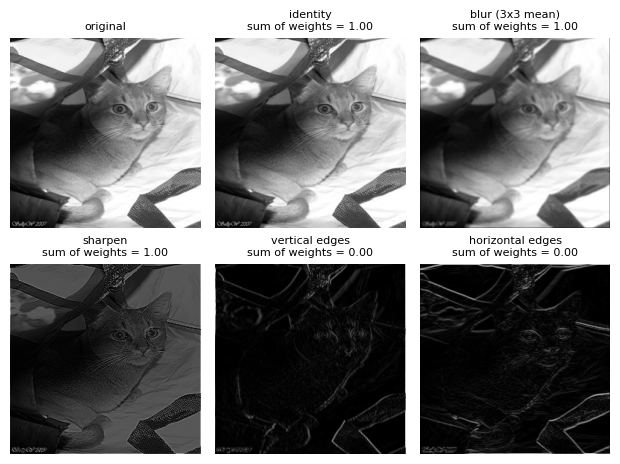

In [2]:
# Load the dataset without any transform: we want the raw PIL images first.
raw_train = datasets.OxfordIIITPet(root="./data", split="trainval", target_types="category", download=True)
raw_test  = datasets.OxfordIIITPet(root="./data", split="test",     target_types="category", download=True)

class_names = raw_train.classes
print("Training images:", len(raw_train), "| Test images:", len(raw_test), "| Classes:", len(class_names))

# One image, converted to grayscale so that we can look at a single channel at a time.
image, label = raw_train[0]
gray = TF.to_tensor(image.resize((256, 256)).convert("L"))[None]        # shape (1, 1, 256, 256)
print("\nExample image:", class_names[label], "| tensor shape fed to conv2d:", tuple(gray.shape))

# Four hand-designed 3x3 kernels.
kernels = {
    "identity":       [[0, 0, 0], [0, 1, 0], [0, 0, 0]],
    "blur (3x3 mean)": [[1 / 9] * 3] * 3,
    "sharpen":        [[0, -1, 0], [-1, 5, -1], [0, -1, 0]],
    "vertical edges": [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],      # Sobel, x direction
    "horizontal edges": [[-1, -2, -1], [0, 0, 0], [1, 2, 1]],    # Sobel, y direction
}

outputs, titles = [gray[0, 0]], ["original"]
for name, k in kernels.items():
    w = torch.tensor(k, dtype=torch.float32).view(1, 1, 3, 3)     # (out_ch, in_ch, kH, kW)
    out = F.conv2d(gray, w, padding=1)                            # <- this is the whole layer
    outputs.append(out[0, 0].abs())
    titles.append(f"{name}\nsum of weights = {w.sum():.2f}")

show_images(outputs, titles=titles, ncols=3, cmap="gray")

### 2 - Shapes

A convolutional layer's output size follows from four numbers. For one spatial dimension:

$$H_{out} = \left\lfloor \frac{H_{in} + 2p - k}{s} \right\rfloor + 1$$

where $k$ is the kernel size, $p$ the padding, and $s$ the stride. The same formula applies to the width,
and to `MaxPool2d` (which is the same sliding-window operation with `max` instead of a weighted sum,
and no parameters).

Two special cases are worth memorizing, because they cover almost everything you will ever build:

- $k=3, s=1, p=1$ leaves the spatial size **unchanged**. This is the default building block.
- $k=3, s=2, p=1$ **halves** the spatial size, and does it inside the convolution rather than with a pooling layer.

The number of **channels** is unrelated to all of this: it is whatever you set `out_channels` to.

In [3]:
# ---------------------------------------------------------------- YOUR DECISION -----
# Fill in kernel_size, stride and padding for two layers, using the formula above.
#
#   layer_same  must map a (3, 224, 224) input to a (16, 224, 224) output
#               -- same spatial size, more channels
#   layer_half  must map a (3, 224, 224) input to a (16, 112, 112) output
#               -- half the spatial size, WITHOUT using a pooling layer
#
# Use a 3x3 kernel for both. The asserts below will tell you whether you got it right,
# but work it out on paper first -- you will be doing this arithmetic for the rest of
# the course, and the formula is faster than trial and error.
layer_same = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
layer_half = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1)
# ------------------------------------------------------------------------------------

x = torch.zeros(1, 3, 224, 224)
print("layer_same:", tuple(layer_same(x).shape[1:]), "| parameters:", sum(p.numel() for p in layer_same.parameters()))
print("layer_half:", tuple(layer_half(x).shape[1:]), "| parameters:", sum(p.numel() for p in layer_half.parameters()))

assert layer_same(x).shape[1:] == (16, 224, 224), "layer_same does not preserve the spatial size"
assert layer_half(x).shape[1:] == (16, 112, 112), "layer_half does not halve the spatial size"
print("\nBoth correct.")

layer_same: (16, 224, 224) | parameters: 448
layer_half: (16, 112, 112) | parameters: 448

Both correct.


Notice something about the parameter counts you just printed: **they are identical**. `layer_half`
processes a quarter as many output positions as `layer_same`, but it has exactly the same number of
weights. The size of the image has nothing to do with the size of the layer.

That is the observation the next question is about.

### 3 - The skeleton we will train, and what it costs

Below is the stack of convolutions we will actually train in Problem 2, stripped down to just the
convolutions and the pooling (in Problem 2 you will decide where the normalization and the dropout go).
Four blocks, each one convolution followed by one 2x2 max-pool, doubling the channels as the spatial
size shrinks -- the standard shape of a small CNN.

Before running the cell, fill in this table on paper. The first row is done for you.

| after | output shape | parameters in that layer |
|---|---|---|
| input | (3, 224, 224) | 0 |
| block 1: Conv(3 -> 32) + Pool | ? | ? |
| block 2: Conv(32 -> 64) + Pool | ? | ? |
| block 3: Conv(64 -> 128) + Pool | ? | ? |
| block 4: Conv(128 -> 128) + Pool | ? | ? |

Every convolution is 3x3 with stride 1 and padding 1; every pool is 2x2 with stride 2. Remember that a
convolution's weight tensor has shape `(out_channels, in_channels, k, k)`, plus one bias per output channel.

In [4]:
def conv_block(in_ch, out_ch):
    """One convolution + one 2x2 max-pool. The skeleton of Problem 2's network."""
    return [nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)]


skeleton = nn.Sequential(*conv_block(3, 32),
                         *conv_block(32, 64),
                         *conv_block(64, 128),
                         *conv_block(128, 128))

shape_trace(skeleton, input_shape=(3, 224, 224))

layer              output shape        params
---------------------------------------------
input             (3, 224, 224)             0
Conv2d           (32, 224, 224)           896
ReLU             (32, 224, 224)             0
MaxPool2d        (32, 112, 112)             0
Conv2d           (64, 112, 112)        18,496
ReLU             (64, 112, 112)             0
MaxPool2d          (64, 56, 56)             0
Conv2d            (128, 56, 56)        73,856
ReLU              (128, 56, 56)             0
MaxPool2d         (128, 28, 28)             0
Conv2d            (128, 28, 28)       147,584
ReLU              (128, 28, 28)             0
MaxPool2d         (128, 14, 14)             0
---------------------------------------------
TOTAL                                 240,832


#### Question 1 &mdash; where did all the parameters go?

The last feature map is `(128, 14, 14)`. Consider the third block's convolution, which maps a
`(64, 56, 56)` input to a `(128, 56, 56)` output, and compare it with an `nn.Linear` layer that maps
the same input to the same output -- every one of the 200,704 input numbers connected to every one of
the 401,408 output numbers.

1. How many parameters does each have? (The convolution's count is printed above; compute the `Linear` one.)
           A: 80.563.859.456
2. The convolution achieves that reduction by making **two** assumptions about images, usually called
   *sparse interaction* (or local connectivity) and *parameter sharing*. Check what each one assumes,
   and which part of `nn.Conv2d`'s definition encodes it.
           A:
               S. I.: Assumes that spatial pixels are locally correlated. Encoded by kernel_size
               P. S.: Assumes that translation invariance-features are equally useful regardles of where they are in the image. Ecoded by sliding the same kernel weights across every spatial position.
3. Both assumptions are *restrictions*: can you think of a limitation of one of these assumptions?
           A: The Spatial Interaction limitation is that it struggles to capture global cntextual relationships between distant parts of an image in early layers, requiring many stacked convolutional layers.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1): a Linear layer's parameter count is `in_features * out_features + out_features`. Multiply it out before you guess -- the answer is larger than you expect. 

</details>

In [5]:
# The receptive field: how much of the input image does ONE unit in the final feature map see?
# Our skeleton, as a list of (kernel_size, stride) pairs in forward order:
layers = [(3, 1), (2, 2)] * 4      # four times: a 3x3 stride-1 conv, then a 2x2 stride-2 pool

rf, jump = receptive_field(layers)
print(f"After 4 blocks: one unit sees a {rf}x{rf} patch of the input image.")
print(f"Neighbouring units in that feature map are {jump} input pixels apart.")
print(f"That patch is {100 * rf / 224:.0f}% of the width of a 224x224 image.")

for n_blocks in range(1, 7):
    r, _ = receptive_field([(3, 1), (2, 2)] * n_blocks)
    print(f"  {n_blocks} block(s): receptive field {r:3d} px")

After 4 blocks: one unit sees a 46x46 patch of the input image.
Neighbouring units in that feature map are 16 input pixels apart.
That patch is 21% of the width of a 224x224 image.
  1 block(s): receptive field   4 px
  2 block(s): receptive field  10 px
  3 block(s): receptive field  22 px
  4 block(s): receptive field  46 px
  5 block(s): receptive field  94 px
  6 block(s): receptive field 190 px


#### Question 2 &mdash; how much can a unit see?

1. A unit in the final feature map sees a 46x46 patch, about a fifth of the image. It is being asked
   to help decide between *Ragdoll* and *Birman*. Do you think a 46x46 patch is enough to tell those apart? If not,
   how do you think the network as a whole ever manage it, given that this is its deepest layer?
       A1: No, as distinguishing between subtle breeds like Ragdoll and Birman requires evaluating spatial context across the entire animal.
       A2: Individual units in the final feature map act as local feature detectors.
2. Modern CNNs almost always use 3x3 kernels stacked deeply, rather than the 7x7 and 11x11 kernels of
   early architectures. Two stacked 3x3 convolutions have the same receptive field as one 5x5. Compare
   them on parameter count.
       A1 (Two of 3x3): 2 x (CxCx3x3) = 18C^2
       A2 ( 5x5 ): (CxCx5x5) = 25C^2
       A3: So, two stacked 3x3 convolutions have the same receptive field as one 5x5, while using 28% fewer parameters.
3. In the printout, the receptive field roughly doubles with each block. Which of the two layers in a
   block -- the convolution or the pool -- is responsible for that doubling, and why?
       A: The MaxPool2d layer, because the single 3x3 convolution with stride 1 only expands the receptive field by a fixed addition of +2 pixels. The pooling layer with a stride of 2 doubles the step size, doubling the rate at which the receptive field expands in all deeper blocks.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), look at what comes *after* the last block in Problem 2's network. For (2), count the weights for `C -> C` channels in both cases, and then ask what sits between the two 3x3 convolutions that cannot sit in the middle of a 5x5 one. For (3), look at which layer changes `jump` in the `receptive_field` code.

</details>

### 4 - The experiment Assignment 0 promised

We have claimed twice now that a convolution *assumes* something about images: that nearby pixels are
related, and that a feature means the same thing wherever it appears. Claims like that are easy to
state and easy to nod along to. Here is how to test one.

**The permutation test.** Pick one random permutation of the pixel positions. Apply that *same*
permutation to every image in the dataset, training and test alike. The images become unrecognisable to
a human. But notice what has *not* changed: the mapping from images to labels is still a perfectly
well-defined function, and it still contains exactly as much information as before -- we have merely
relabelled the input coordinates.

So a model that treats its input as an unordered list of numbers should be completely unaffected.
A model that relies on the spatial arrangement should fall apart.

We will train four models -- an MLP and a CNN, each on the original and on the permuted pixels -- and
compare. Before you run it, write down your prediction for all four numbers.

Materialized in 12s: (3680, 3, 112, 112) train, (3669, 3, 112, 112) test


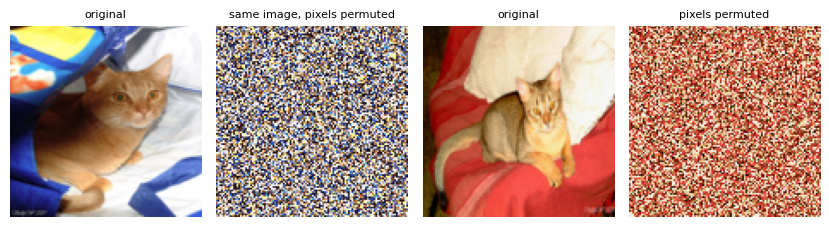

In [6]:
# Materialize the whole dataset once as tensors at reduced resolution, so that the four
# training runs below are pure GPU work with no repeated JPEG decoding.
PERM_RES = 112

perm_tf = transforms.Compose([transforms.Resize((PERM_RES, PERM_RES)),
                              transforms.ToTensor(),
                              transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

def materialize(split):
    ds = datasets.OxfordIIITPet(root="./data", split=split, transform=perm_tf, download=False)
    loader = DataLoader(ds, batch_size=128, num_workers=4)
    xs, ys = zip(*[(x, y) for x, y in loader])
    return torch.cat(xs), torch.cat(ys)

t0 = time.time()
X_tr_perm_task, y_tr_perm_task = materialize("trainval")
X_te_perm_task, y_te_perm_task = materialize("test")
print(f"Materialized in {time.time() - t0:.0f}s: {tuple(X_tr_perm_task.shape)} train, "
      f"{tuple(X_te_perm_task.shape)} test")

# ONE permutation of the PERM_RES * PERM_RES pixel positions, reused for every image and
# every colour channel. This is the crucial detail: it is a fixed relabelling of the
# coordinates, not random noise added per image.
pixel_perm = torch.randperm(PERM_RES * PERM_RES, generator=torch.Generator().manual_seed(0))

def shuffle_pixels(X):
    n, c = X.shape[:2]
    return X.reshape(n, c, -1)[:, :, pixel_perm].reshape(n, c, PERM_RES, PERM_RES)

X_tr_shuf = shuffle_pixels(X_tr_perm_task)
X_te_shuf = shuffle_pixels(X_te_perm_task)

# What the network is now being asked to classify:
show_images([denormalize(X_tr_perm_task[0]), denormalize(X_tr_shuf[0]),
             denormalize(X_tr_perm_task[3]), denormalize(X_tr_shuf[3])],
            titles=["original", "same image, pixels permuted", "original", "pixels permuted"], ncols=4)

In [7]:
def perm_mlp():
    """A flattened MLP: exactly the kind of model you built in Assignment 0."""
    return nn.Sequential(nn.Flatten(),
                         nn.Linear(3 * PERM_RES * PERM_RES, 512), nn.ReLU(),
                         nn.Linear(512, len(class_names)))


def perm_cnn():
    """The Problem 1 skeleton with batch norm, plus a global pool and a classifier."""
    def block(i, o):
        return [nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(), nn.MaxPool2d(2)]
    return nn.Sequential(*block(3, 32), *block(32, 64), *block(64, 128), *block(128, 128),
                         nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                         nn.Linear(128, len(class_names)))


def quick_train(make_model, X_train, X_test, epochs=40, lr=1e-3, tag=""):
    """Train from in-memory tensors and return the final test accuracy."""
    set_seed(0)
    model = make_model().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(torch.utils.data.TensorDataset(X_train, y_tr_perm_task),
                             batch_size=64, shuffle=True)
    test_loader = DataLoader(torch.utils.data.TensorDataset(X_test, y_te_perm_task), batch_size=256)

    for _ in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad()
            criterion(model(x), y).backward()
            optimizer.step()

    train_acc, _ = evaluate(model, DataLoader(torch.utils.data.TensorDataset(X_train, y_tr_perm_task),
                                              batch_size=256))
    acc, _ = evaluate(model, test_loader)
    print(f"  {tag:<26s} train accuracy {train_acc:.4f}   test accuracy {acc:.4f}")
    return acc


print(f"Chance level for {len(class_names)} classes: {1 / len(class_names):.4f}\n")
print("This takes a few minutes -- four models trained to convergence.\n")

results = {}
results["MLP, original"] = quick_train(perm_mlp, X_tr_perm_task, X_te_perm_task, tag="MLP, original pixels")
results["MLP, permuted"] = quick_train(perm_mlp, X_tr_shuf,      X_te_shuf,      tag="MLP, permuted pixels")
results["CNN, original"] = quick_train(perm_cnn, X_tr_perm_task, X_te_perm_task, tag="CNN, original pixels")
results["CNN, permuted"] = quick_train(perm_cnn, X_tr_shuf,      X_te_shuf,      tag="CNN, permuted pixels")

print(f"\nMLP: {results['MLP, original']:.4f} -> {results['MLP, permuted']:.4f}"
      f"  ({100 * (results['MLP, permuted'] - results['MLP, original']):+.1f} points)")
print(f"CNN: {results['CNN, original']:.4f} -> {results['CNN, permuted']:.4f}"
      f"  ({100 * (results['CNN, permuted'] - results['CNN, original']):+.1f} points)")

Chance level for 37 classes: 0.0270

This takes a few minutes -- four models trained to convergence.

  MLP, original pixels       train accuracy 0.9160   test accuracy 0.0984
  MLP, permuted pixels       train accuracy 0.9242   test accuracy 0.0853
  CNN, original pixels       train accuracy 0.4481   test accuracy 0.1750
  CNN, permuted pixels       train accuracy 0.3098   test accuracy 0.0777

MLP: 0.0984 -> 0.0853  (-1.3 points)
CNN: 0.1750 -> 0.0777  (-9.7 points)


#### Question 3 &mdash; reading the permutation test

You should see something close to this (your numbers will vary a little):

| model | original pixels | permuted pixels |
|---|---|---|
| MLP | 0.080 | 0.087 |
| CNN | 0.174 | 0.081 |

1. The MLP's score did not move. Explain why, in terms of what its first `nn.Linear` layer does.
   Your explanation should be strong enough to predict that the change is *exactly* zero in principle,
   not merely small.
       A: A linear layer computes y = Wx+b. Permuting the pixels permutes the entries of the input vector x via a permutation matrix. The network can achieve the exact same mathematical function by simply permuting the columns of its first weight matrix.
2. The CNN lost around 9 points -- and landed almost exactly on the MLP's score. Why is that particular
   coincidence the most informative part of the whole table?
       A: When spatial locality is destroyed, the CNN is stripped of its spatial inductive bias. Landing in the MLP's score demonstrates that a CNN operating on spatial noise degrades to nothing more than a inefficient feature aggregator, proving that the CNN's performance on real images comes entirely from exploiting spatial structure, not extra capacity or depth.
3. Which of the four numbers is the *good* news about convolutions, and which is the *bad* news about
   this dataset? (Look at the absolute values, not just the differences.)
       A:
           Good: The CNN's performance on original pixels proves that convolutions effectively capture visual hierarchy and spatial patterns with far fewer features.
           Bad: The absolute baseline performance is extremely low compared to human performance. 
4. Suppose you ran this test on a dataset and the CNN did **not** degrade. What would you conclude, and
   what would you do about your architecture?
       A: The dataset's targets do not depend on spatial relationships or local visual structure. I would drop the convolutional layers altogether in favor of simpler tabular/stadistical models or standard MLPs.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), write down what the first layer computes as a sum over input pixels, and ask what happens if you permute both the pixels and the corresponding weight columns. For (4), think of a data type where the input is genuinely an unordered list of measurements.

</details>

## Problem 2.  The data, and a CNN trained from scratch

Now we look at the data, build the input pipeline, and train the skeleton from Problem 1.

The exploratory analysis in Assignment 0 was easy: 28x28 grayscale images, all the same size, perfectly
balanced, and a per-class mean image that was actually informative. Almost none of that is true here.
Real photographs bring their own questions, and each one forces a preprocessing decision.

### 1 - Exploratory data analysis

**The dataset.** The Oxford-IIIT Pet dataset contains 7,349 photographs of 37 cat and dog breeds,
collected by Parkhi et al. (2012). It is a **fine-grained** classification problem: the classes are not
"cat" and "dog" but "Ragdoll" and "Birman", which differ by markings that a non-expert human often
cannot name.

It comes pre-split into `trainval` (3,680 images) and `test` (3,669). We will further split `trainval` into a training and a validation set,
which gives us the three-way split that any honest experiment needs:

- **train** -- the model fits these.
- **validation** -- we look at these to make decisions (when to stop, which architecture, which learning rate).
- **test** -- we look at these **once**, at the very end, to report a number.

Let's start with the class distribution.

Images per breed in trainval -- min: 93, max: 100, mean: 99.5
Cat breeds: 12, dog breeds: 25
Cat images: 1188 (32.3%), dog images: 2492 (67.7%)


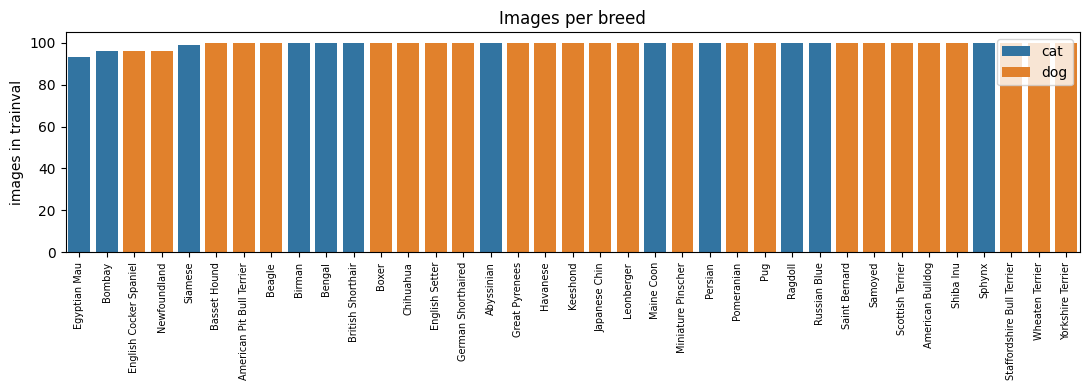

In [8]:
# Cats vs dogs: 12 of the 37 breeds are cats. The dataset does not expose this grouping
# directly, so we list it (the original annotation file encodes it as a SPECIES column).
CAT_BREEDS = {"Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair", "Egyptian Mau",
              "Maine Coon", "Persian", "Ragdoll", "Russian Blue", "Siamese", "Sphynx"}
is_cat = np.array([c in CAT_BREEDS for c in class_names])

y_trainval = np.array(raw_train._labels)
y_test     = np.array(raw_test._labels)

counts = np.bincount(y_trainval, minlength=len(class_names))
print("Images per breed in trainval -- min: %d, max: %d, mean: %.1f" % (counts.min(), counts.max(), counts.mean()))
print("Cat breeds: %d, dog breeds: %d" % (is_cat.sum(), (~is_cat).sum()))
n_cat = counts[is_cat].sum()
n_dog = counts[~is_cat].sum()
print("Cat images: %d (%.1f%%), dog images: %d (%.1f%%)"
      % (n_cat, 100 * n_cat / len(y_trainval), n_dog, 100 * n_dog / len(y_trainval)))

plt.figure(figsize=(11, 4))
order = np.argsort(counts)
sns.barplot(x=[class_names[i] for i in order], y=counts[order],
            hue=["cat" if is_cat[i] else "dog" for i in order], dodge=False)
plt.xticks(rotation=90, fontsize=7)
plt.ylabel("images in trainval")
plt.title("Images per breed")
plt.tight_layout()
plt.show()

#### Question 4 &mdash; how balanced is balanced enough?

The breeds are close to balanced (roughly 100 images each), but the *species* are not: about a third
of the images are cats and two thirds are dogs.

1. Suppose we were doing the binary cat-vs-dog task instead. A colleague reports 68% accuracy. What is
   the first thing you should ask, and what is the number you need in order to know whether 68% is any good?
            A: The distribution of each class in the test set. You need the mayority class baseline accuracy. Since dogs are 2/3 (66.6%) of the dataset, a naive model that predicts dog for every single image would achieve 66.7% accuracy without learning any visual features. THus, a 68% accuracy is barely better than a constant baseline.
2. Three standard responses to class imbalance are: **resampling** the data (oversample the minority
   or undersample the majority), a **class-weighted loss** (`nn.CrossEntropyLoss(weight=...)`), and
   **reporting a different metric** (macro-F1 instead of accuracy). One of these does *not* change what
   the model learns at all. Which one, and what is it for then?
           A: Reporting a different metric. It is used as an evaluation tool. It leaves the learned model parameters untouched. It treats all classes equally, exposing wheteher a high-accuracy model is simply ignoring minority classes.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), work out what a model that ignores its input entirely would score. For (2), ask which of the three appears anywhere in the training loop.

</details>

Widths  -- min: 117, max: 2560, median: 500
Heights -- min: 149, max: 1920, median: 375
Aspect ratio (w/h) -- min: 0.57, max: 1.78, median: 1.33
Portrait: 29% | Landscape: 69% | Square: 2%


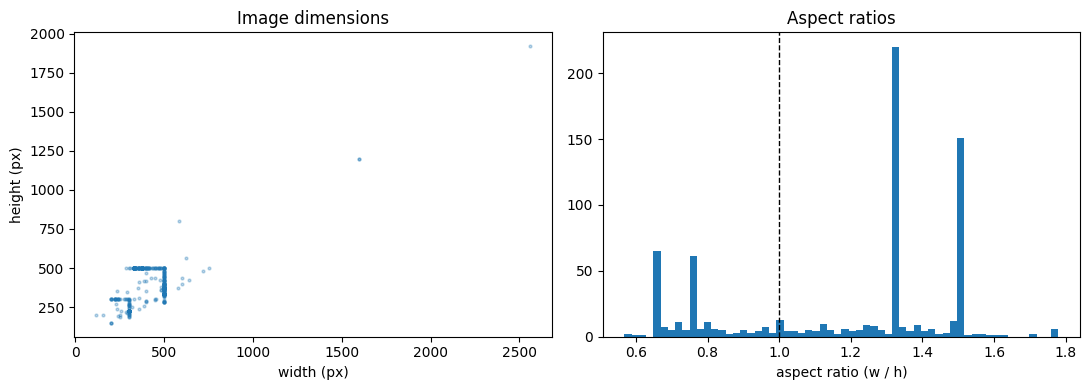

In [9]:
# Real photographs do not all have the same shape. Let's find out what we are dealing with.
sizes = np.array([raw_train[i][0].size for i in range(0, len(raw_train), 5)])   # every 5th image
widths, heights = sizes[:, 0], sizes[:, 1]
aspect = widths / heights

print("Widths  -- min: %d, max: %d, median: %d" % (widths.min(), widths.max(), np.median(widths)))
print("Heights -- min: %d, max: %d, median: %d" % (heights.min(), heights.max(), np.median(heights)))
print("Aspect ratio (w/h) -- min: %.2f, max: %.2f, median: %.2f" % (aspect.min(), aspect.max(), np.median(aspect)))
print("Portrait: %.0f%% | Landscape: %.0f%% | Square: %.0f%%"
      % (100 * (aspect < 0.98).mean(), 100 * (aspect > 1.02).mean(),
         100 * ((aspect >= 0.98) & (aspect <= 1.02)).mean()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(widths, heights, s=4, alpha=0.3)
axes[0].set_xlabel("width (px)"); axes[0].set_ylabel("height (px)"); axes[0].set_title("Image dimensions")
axes[1].hist(aspect, bins=60)
axes[1].axvline(1.0, color="k", ls="--", lw=1)
axes[1].set_xlabel("aspect ratio (w / h)"); axes[1].set_title("Aspect ratios")
plt.tight_layout()
plt.show()

Every image has a different shape, but a convolutional network needs a fixed input size -- not because
of the convolutions (those work on any size) but because the classifier at the end expects a fixed
number of features, and because batching requires all tensors in a batch to have the same shape.

So we must resize. There are three standard ways to do it, and they lose different things:

- **Squash**: `Resize((H, W))`. Keeps every pixel of content, distorts the aspect ratio.
- **Crop**: `Resize(shorter_side)` then `CenterCrop`. Keeps the aspect ratio, throws away the edges.
- **Pad**: pad to a square with a constant colour, then resize. Keeps everything and the aspect ratio,
  at the cost of feeding the network bands of meaningless pixels.

Let's look at all three on one image before deciding.

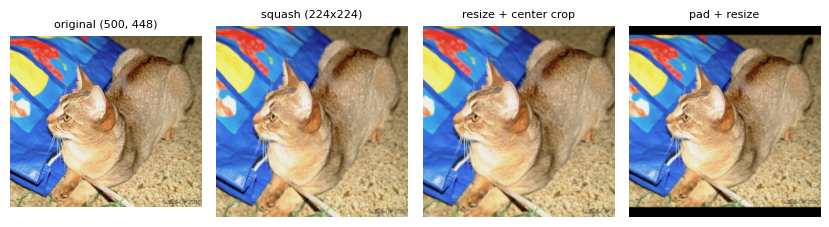

Class: Abyssinian


In [10]:
def pad_to_square(img, fill=0):
    """Pad a PIL image with a constant colour until it is square."""
    w, h = img.size
    side = max(w, h)
    left, top = (side - w) // 2, (side - h) // 2
    return TF.pad(img, [left, top, side - w - left, side - h - top], fill=fill)


demo_idx = 7
demo_img, demo_label = raw_train[demo_idx]
variants = [
    demo_img,
    TF.resize(demo_img, [224, 224]),                                  # squash
    TF.center_crop(TF.resize(demo_img, 224), [224, 224]),             # crop
    TF.resize(pad_to_square(demo_img), [224, 224]),                   # pad
]
titles = [f"original {demo_img.size}", "squash (224x224)", "resize + center crop", "pad + resize"]
show_images(variants, titles=titles, ncols=4)
print("Class:", class_names[demo_label])

In [11]:
# ---------------------------------------------------------------- YOUR DECISION -----
# Two choices that everything downstream depends on.
#
# IMG_SIZE -- the side length we resize to. 224 is the conventional choice, and it is what
#             the pretrained networks in Problem 4 expect. Smaller is faster (cost grows
#             with the SQUARE of this number) but throws away detail, and this is a
#             fine-grained problem where the detail may be the whole answer.
#             If you are on CPU, use 96 or 128 and accept lower accuracy.
#
# RESIZE_MODE -- "squash", "crop" or "pad". Look at the three panels above, think about
#                where the animal usually sits in a pet photograph, and about which
#                distortion a convolution is most likely to cope with. There is a
#                defensible case for more than one answer -- make yours and say why.
IMG_SIZE    = 224
RESIZE_MODE = "crop"
# ------------------------------------------------------------------------------------

def base_transform(img_size, mode):
    """The resize policy, shared by train, validation and test."""
    if mode == "squash":
        return [transforms.Resize((img_size, img_size))]
    if mode == "crop":
        return [transforms.Resize(img_size), transforms.CenterCrop(img_size)]
    if mode == "pad":
        return [transforms.Lambda(pad_to_square), transforms.Resize((img_size, img_size))]
    raise ValueError(f"unknown resize mode: {mode}")

print("Resizing to %dx%d using the '%s' policy." % (IMG_SIZE, IMG_SIZE, RESIZE_MODE))

Resizing to 224x224 using the 'crop' policy.


#### Question 5 &mdash; what did resizing cost you?

You just made a decision that destroys information, and every image in the rest of this notebook
goes through it.

1. Name one thing each of the three policies destroys. For your chosen policy, describe a specific
   photograph in this dataset where that loss could plausibly change the prediction.
           A:
               Squash: Destroys geometric aspect ratios and scale proportions.
               Crop: Destroys peripheral image content.
               Pad: Destroys effective spatial resolution and computational density.
           A2: I chose crop, so I think maybe a photograph of a long-haired dog breed in which it is possitioned where key distinguising features reside near the oter third of the image.
2. Whatever you chose, you must apply the **same** policy to the training, validation and test sets.
   Why is this not optional? (In Problem 3 we will break this rule on purpose, for exactly one set.)
           A: Because, for example, if you train a model on cropped images and evaluate it on squashed or padded images, you would be introducing an artificial covariate shift.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (2), remember the normalization argument from Assignment 0 -- the same principle applies to every preprocessing step.

</details>

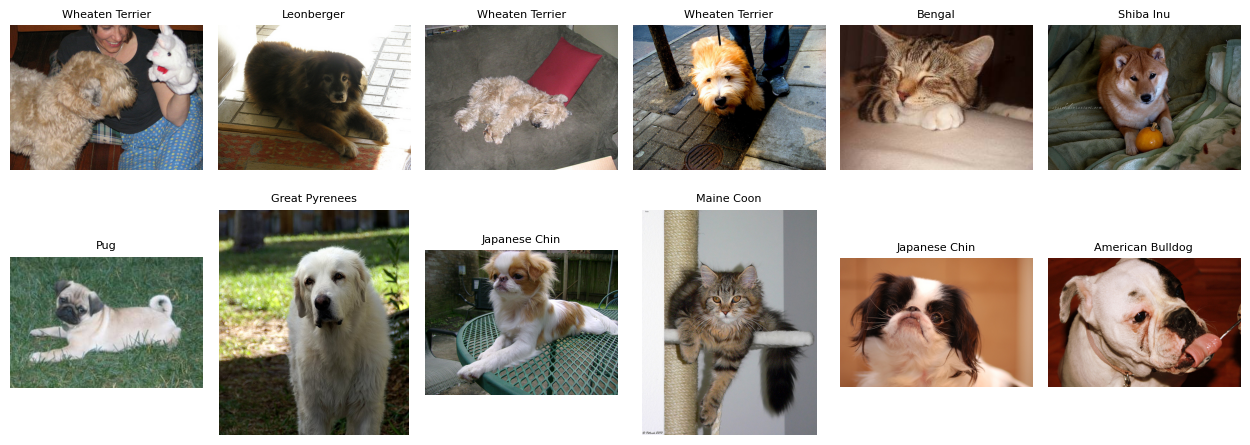

In [12]:
# A sample grid. Look at these properly -- the next question asks you to make a prediction from them.
set_seed(1)
sample_idx = np.random.choice(len(raw_train), 12, replace=False)
imgs   = [raw_train[i][0] for i in sample_idx]
titles = [class_names[raw_train[i][1]] for i in sample_idx]
show_images(imgs, titles=titles, ncols=6)

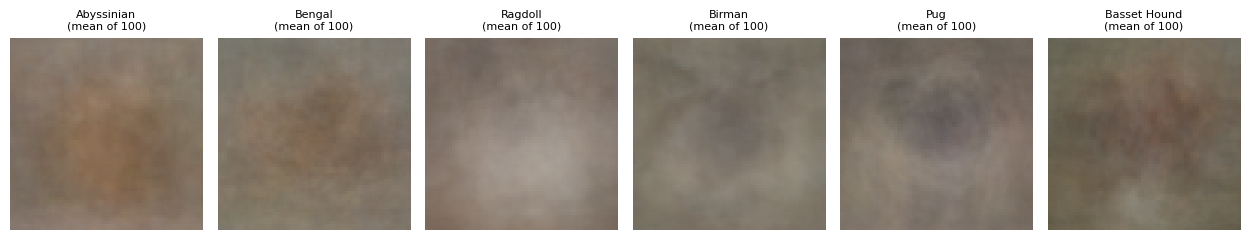

In [13]:
# In Assignment 0 the per-class MEAN IMAGE was informative: averaging 6,000 Fashion-MNIST
# trousers gave a recognisable trouser, and comparing the mean images told us which classes
# would be confused. Let's try the same trick here.
to_small = transforms.Compose(base_transform(64, RESIZE_MODE) + [transforms.ToTensor()])

mean_images, mean_titles = [], []
for cls in [0, 5, 26, 6, 25, 3]:           # Abyssinian, Bengal, Ragdoll, Birman, Pug, Basset Hound
    idx = np.where(y_trainval == cls)[0]
    stack = torch.stack([to_small(raw_train[i][0]) for i in idx])
    mean_images.append(stack.mean(dim=0))
    mean_titles.append(f"{class_names[cls]}\n(mean of {len(idx)})")

show_images(mean_images, titles=mean_titles, ncols=6)

#### Question 6 &mdash; predict before you train

Two things to commit to in writing, before any training happens.

1. The mean images above are brown mush, and they all look the same. In Assignment 0 the same plot was
   genuinely useful. What property did Fashion-MNIST have that this dataset does not?
           A: Because the images were tightly normalized, centered, simple and they didn't have many pixels.
2. From the sample grid and your own knowledge of cats and dogs: name **two pairs of breeds** you expect
   the final model to confuse, and **one breed** you expect it to get nearly right. Write down your
   reasoning, not just the names.
           A1: Ragdoll and Birman: Both are long-haired cat breeds with similar color patterns.
           A2: American Pitbull Terrier and Staffordshire Bull Terrier: They both have muscular builds and identical facial structure and head shapes
           A3: Sphynx: It has a unique body, since it is hairless with large prominent ears.

Keep this answer. At the end of Problem 4 there is a confusion matrix, and you will check it against
this prediction.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1): what has to be true of a set of images for their average to look like anything at all? Think about where the animal is, how large it is, and which way it is facing, and compare that with a Fashion-MNIST trouser.

</details>

### 2 - Normalization, splitting, and the input pipeline

Three more preprocessing decisions, then we can build the pipeline.

**Scaling.** `transforms.ToTensor()` already converts a PIL image to a float tensor in `[0, 1]`, so the
division by 255 you did by hand in Assignment 0 is taken care of.

**Normalization.** As in Assignment 0, we then subtract a mean and divide by a standard deviation --
but now there are three channels, so we need three of each. And now there is a choice about *where those
six numbers come from*, which did not arise before.

**Splitting.** `trainval` must be split into train and validation. We use `train_test_split` with
`stratify`, so that both halves contain the same proportion of every breed. With about 100 images per
class, an unstratified random split could easily leave a class with 12 validation images and another
with 28, making per-class validation metrics very noisy.

In [14]:
# The dataset's own channel statistics, computed on the TRAINING portion only.
# (We need the split first, so we do the split here too.)
set_seed(0)
train_idx, val_idx = train_test_split(np.arange(len(y_trainval)),
                                      test_size=0.2,
                                      stratify=y_trainval,      # same class proportions in both halves
                                      shuffle=True,
                                      random_state=0)
print("train: %d images | validation: %d images | test: %d images"
      % (len(train_idx), len(val_idx), len(raw_test)))

# Sanity check that stratification worked
tr_counts = np.bincount(y_trainval[train_idx], minlength=37)
va_counts = np.bincount(y_trainval[val_idx], minlength=37)
print("per-class train counts: %d-%d | per-class val counts: %d-%d"
      % (tr_counts.min(), tr_counts.max(), va_counts.min(), va_counts.max()))

stat_tf = transforms.Compose(base_transform(IMG_SIZE, RESIZE_MODE) + [transforms.ToTensor()])
stat_ds = datasets.OxfordIIITPet(root="./data", split="trainval", transform=stat_tf, download=False)
stat_loader = DataLoader(Subset(stat_ds, train_idx), batch_size=128, num_workers=4)

total, total_sq, n_pixels = torch.zeros(3), torch.zeros(3), 0
for x, _ in stat_loader:
    total    += x.sum(dim=[0, 2, 3])
    total_sq += (x ** 2).sum(dim=[0, 2, 3])
    n_pixels += x.shape[0] * x.shape[2] * x.shape[3]

pet_mean = total / n_pixels
pet_std  = (total_sq / n_pixels - pet_mean ** 2).sqrt()

print("\nOxford-IIIT Pet (training split) -- mean: [%.3f, %.3f, %.3f]  std: [%.3f, %.3f, %.3f]"
      % (*pet_mean, *pet_std))
print("ImageNet (1.2M photographs)      -- mean: [%.3f, %.3f, %.3f]  std: [%.3f, %.3f, %.3f]"
      % (*IMAGENET_MEAN, *IMAGENET_STD))

train: 2944 images | validation: 736 images | test: 3669 images
per-class train counts: 74-80 | per-class val counts: 19-20

Oxford-IIIT Pet (training split) -- mean: [0.484, 0.448, 0.398]  std: [0.261, 0.256, 0.264]
ImageNet (1.2M photographs)      -- mean: [0.485, 0.456, 0.406]  std: [0.229, 0.224, 0.225]


In [15]:
# ---------------------------------------------------------------- YOUR DECISION -----
# Which mean and standard deviation should the pipeline use?
#
#   pet_mean / pet_std          -- measured on THIS dataset's training split, just above
#   IMAGENET_MEAN / IMAGENET_STD -- measured once on the 1.2M-image ImageNet training set,
#                                   and hard-coded into essentially every vision codebase
#
# Compare the two printouts. Then argue for one. Both are defensible right now -- but in
# Problem 4 one of them stops being a free choice, and it is worth trying to predict which
# and why before you get there.
NORM_MEAN, NORM_STD = pet_mean, pet_std
# ------------------------------------------------------------------------------------

def make_transform(img_size, mode, augment=None):
    """
    Assemble the full transform: resize -> (optional augmentation) -> tensor -> normalize.
    `augment` is a list of transforms inserted before ToTensor(); we will use it in Problem 3.
    """
    steps = base_transform(img_size, mode)
    steps += list(augment or [])
    steps += [transforms.ToTensor(), transforms.Normalize(NORM_MEAN, NORM_STD)]
    return transforms.Compose(steps)


eval_transform = make_transform(IMG_SIZE, RESIZE_MODE)          # no augmentation, ever
print(eval_transform)

Compose(
    Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=tensor([0.4838, 0.4480, 0.3982]), std=tensor([0.2612, 0.2559, 0.2635]))
)


#### Question 7 &mdash; which mean and standard deviation?

The cell above printed two rows of six numbers each. In both cases the six numbers are the
**per-channel mean and standard deviation of the pixel values**: one mean and one standard deviation
for red, for green, and for blue, averaged over every pixel of every image in some collection of
photographs. `transforms.Normalize` uses them to rescale each channel, subtracting the mean and
dividing by the standard deviation, so that the values fed to the network are centred near zero with a
spread near one -- the same thing you did by hand in Assignment 0, but per channel.

The two rows differ in **which collection of photographs they were measured on**:

- `pet_mean` / `pet_std` come from the 2,944 training images of *this* dataset.
- `IMAGENET_MEAN` / `IMAGENET_STD` come from the 1.2 million photographs of ImageNet, a completely
  different dataset, and are hard-coded into essentially every computer-vision codebase.

That second option should look suspicious. Assignment 0 was strict about computing statistics on the
training set and merely *applying* them to the test set, because doing anything else leaks information
about the test set into the model.

1. Is using the ImageNet numbers a form of data leakage? Answer carefully: what would have to be true
   about where those numbers came from for it to count as leakage?
           A: No, it is not data leakage. It occurs specifically when information from the current test set leaks into the training pipeline. The ImageNet statistics were calculated on a completely independent external dataset.
2. In `make_transform`, normalization is applied **after** `ToTensor()`, while the augmentation you will
   add in Problem 3 goes **before** it. Why does that order matter?
           A: Pytorch's image augmentation functions expect raw PIL images or integer pixel ranges as input. The order matter because ToTensor() converts the PIL image (0 to 255) into a torch.Tensor scaled to [0.0, 1.0]. Then, transforms.Normalize() is a numerical matrix operation that operates on standard PyTorch floating-point tensors, shifting them to zero-mean and unit-variance. Applying normalization before ToTensor() would fail because PIL images cannot store negative floating-point numbers.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), ask which images the numbers were computed from, and whether *those* images overlap with the test set you are going to report a number on. For (2), `ToTensor()` is what turns a PIL image into a tensor -- ask what a random crop or a colour jitter expects to receive, and what `Normalize` expects to receive.

</details>

In [16]:
# ---------------------------------------------------------------- YOUR DECISION -----
# The DataLoader settings.
#
#   BATCH_SIZE  -- how many images per parameter update. In Assignment 0 you saw why
#                  mini-batches beat full-batch. 32-128 is the conventional range; the
#                  ceiling here is GPU memory, which scales with BATCH_SIZE * IMG_SIZE^2.
#   NUM_WORKERS -- how many background processes decode and resize JPEGs. 0 means the
#                  main process does it, in between GPU steps, so the GPU sits idle while
#                  it waits. A small number (2-4) is usually enough to keep the GPU fed;
#                  far more than the machine has cores does not keep helping.
#   shuffle     -- set separately for train and validation. One of them should be True
#                  and one should be False. Which, and why does it matter for neither
#                  correctness nor speed in one of the two cases?
BATCH_SIZE  = 64
NUM_WORKERS = 4
SHUFFLE_TRAIN = True
SHUFFLE_VAL   = False
# ------------------------------------------------------------------------------------

def build_loaders(train_augment=None, batch_size=None, num_workers=None):
    """
    Build the three DataLoaders. Note that the training set gets `train_augment`, while
    validation and test always use `eval_transform`.
    """
    batch_size = batch_size or BATCH_SIZE
    num_workers = NUM_WORKERS if num_workers is None else num_workers
    train_tf = make_transform(IMG_SIZE, RESIZE_MODE, augment=train_augment)

    train_ds = Subset(datasets.OxfordIIITPet(root="./data", split="trainval", transform=train_tf), train_idx)
    val_ds   = Subset(datasets.OxfordIIITPet(root="./data", split="trainval", transform=eval_transform), val_idx)
    test_ds  = datasets.OxfordIIITPet(root="./data", split="test", transform=eval_transform)

    common = dict(num_workers=num_workers, pin_memory=True,
                  persistent_workers=num_workers > 0)
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=SHUFFLE_TRAIN, **common),
            DataLoader(val_ds,   batch_size=batch_size, shuffle=SHUFFLE_VAL,   **common),
            DataLoader(test_ds,  batch_size=batch_size, shuffle=False,         **common))


train_loader, val_loader, test_loader = build_loaders()
print("Batches per epoch -- train: %d, val: %d, test: %d"
      % (len(train_loader), len(val_loader), len(test_loader)))
print("Parameter updates per epoch:", len(train_loader))

Batches per epoch -- train: 46, val: 12, test: 58
Parameter updates per epoch: 46


### 3 - A CNN trained from scratch

Now we assemble the network. The skeleton from Problem 1 is the same; what you decide here is what goes
*around* the convolutions.

**Batch normalization.** After a convolution, `nn.BatchNorm2d` standardizes each channel using the mean
and variance of the current batch, then applies a learned scale and shift. It makes deep networks far
easier to optimize -- larger learning rates become usable and the network is much less sensitive to how
the weights were initialized. It also behaves differently in training and evaluation mode, which is why
`train_model` calls `model.train()` and `model.eval()`.

**Dropout.** During training, `nn.Dropout(p)` zeroes each activation independently with probability `p`.
It is a regularizer: the network cannot rely on any single unit being present, so it is pushed towards
redundant, distributed representations.

**The head.** After four blocks we have a `(128, 14, 14)` feature map and we need 37 numbers. Two ways:

- `Flatten()` then `Linear(128*14*14, 256)` -- keeps the spatial positions as separate features.
- `AdaptiveAvgPool2d(1)` then `Flatten()` then `Linear(128, 256)` -- averages each channel over all
  positions, answering "how much of this feature is present anywhere in the image?"

Count the parameters of both before you choose.

In [17]:
# ---------------------------------------------------------------- YOUR DECISION -----
# Three choices about the architecture. The helper below assembles the network from them,
# so you only have to decide -- not to write layer code.
#
# BLOCK_ORDER -- the order of the three components inside one convolutional block.
#                Both of these are seen in real code:
#                    ["conv", "bn", "relu"]   or   ["conv", "relu", "bn"]
#                Think about what BatchNorm does (centres the values around zero) and what
#                ReLU does (deletes everything below zero), and about what happens to the
#                normalization if you apply them the other way round.
#                The pooling always goes last.
#
# HEAD        -- "flatten" or "global_pool". Print the parameter count for both before
#                choosing, and ask which of the two is consistent with the answer you gave
#                to Question 1.
#
# DROPOUT_P   -- probability of dropping an activation in the classifier, in [0.0, 0.7].
#                0.0 disables it. This is a regularizer, so the right question is: are we
#                overfitting? Look at Problem 1's MLP train-vs-test gap before you answer.
BLOCK_ORDER = ["conv", "bn", "relu"]
HEAD        = "global_pool"
DROPOUT_P   = 0.5
# ------------------------------------------------------------------------------------

def build_cnn(block_order, head, dropout_p, channels=(32, 64, 128, 128), n_classes=37):
    """Assemble the CNN from the three decisions above."""
    parts = {"conv": lambda i, o: nn.Conv2d(i, o, kernel_size=3, stride=1, padding=1),
             "bn":   lambda i, o: nn.BatchNorm2d(o),
             "relu": lambda i, o: nn.ReLU()}

    layers, in_ch = [], 3
    for out_ch in channels:
        for name in block_order:
            layers.append(parts[name](in_ch, out_ch))
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        in_ch = out_ch

    spatial = IMG_SIZE // (2 ** len(channels))
    if head == "flatten":
        layers += [nn.Flatten()]
        n_features = in_ch * spatial * spatial
    elif head == "global_pool":
        layers += [nn.AdaptiveAvgPool2d(1), nn.Flatten()]
        n_features = in_ch
    else:
        raise ValueError(f"unknown head: {head}")

    layers += [nn.Dropout(dropout_p), nn.Linear(n_features, 256), nn.ReLU(), nn.Linear(256, n_classes)]
    return nn.Sequential(*layers)


# What each head costs, before you commit:
for h in ["flatten", "global_pool"]:
    m = build_cnn(["conv", "bn", "relu"], h, 0.0)
    print(f"head={h:12s} -> {count_params(m)[0]:>10,} parameters")

set_seed(0)
cnn_scratch = build_cnn(BLOCK_ORDER, HEAD, DROPOUT_P)
print()
shape_trace(cnn_scratch, input_shape=(3, IMG_SIZE, IMG_SIZE))

head=flatten      ->  6,673,829 parameters
head=global_pool  ->    284,069 parameters

layer                      output shape        params
-----------------------------------------------------
input                     (3, 224, 224)             0
Conv2d                   (32, 224, 224)           896
BatchNorm2d              (32, 224, 224)            64
ReLU                     (32, 224, 224)             0
MaxPool2d                (32, 112, 112)             0
Conv2d                   (64, 112, 112)        18,496
BatchNorm2d              (64, 112, 112)           128
ReLU                     (64, 112, 112)             0
MaxPool2d                  (64, 56, 56)             0
Conv2d                    (128, 56, 56)        73,856
BatchNorm2d               (128, 56, 56)           256
ReLU                      (128, 56, 56)             0
MaxPool2d                 (128, 28, 28)             0
Conv2d                    (128, 28, 28)       147,584
BatchNorm2d               (128, 28, 28)          

Now the optimization. Two notes on things that are given rather than chosen:

**The loss.** `nn.CrossEntropyLoss` -- for the same reasons as in Assignment 0. It takes raw logits, so
the network must **not** end in a softmax.

**The learning-rate schedule.** It is standard to decay the learning rate as training progresses: large
steps early to cover ground, small steps later to settle. `ExponentialLR(optimizer, gamma)` multiplies
the learning rate by `gamma` after every epoch, so after 60 epochs with `gamma=0.95` the rate is
`0.95^60 = 4.6%` of where it started.

In [18]:
# ---------------------------------------------------------------- YOUR DECISION -----
# The optimizer and the schedule.
#
#   OPTIMIZER    -- "sgd" (with momentum 0.9) or "adam". Adam adapts a per-parameter step
#                   size and usually needs a much smaller learning rate than SGD. There is
#                   no universally right answer; there is a right *pairing* of optimizer
#                   and learning rate.
#   LEARNING_RATE -- for SGD+momentum on a batch-normalized CNN, 0.01-0.1 is the usual range.
#                    For Adam, 1e-4 to 1e-3. Getting this wrong by 10x is the single most
#                    common reason a network does not train, so if the loss does not move --
#                    or explodes to nan -- suspect this line first.
#   GAMMA        -- per-epoch learning-rate decay, in (0, 1]. Use 1.0 for no decay.
#   N_EPOCHS     -- one pass over 2,944 images is 46 updates, so epochs here are cheap and
#                   you need a lot of them. Around 60 gets the curves into interesting
#                   territory (roughly 2-3 minutes on a GPU).
OPTIMIZER     = "adam"
LEARNING_RATE = 1e-3
GAMMA         = 0.95
N_EPOCHS      = 60
# ------------------------------------------------------------------------------------

def make_optimizer(model, name, lr):
    if name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    if name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr)
    raise ValueError(f"unknown optimizer: {name}")


set_seed(0)
cnn_scratch = build_cnn(BLOCK_ORDER, HEAD, DROPOUT_P)
criterion = nn.CrossEntropyLoss()
optimizer = make_optimizer(cnn_scratch, OPTIMIZER, LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=GAMMA)

print("Trainable parameters: %d\n" % count_params(cnn_scratch)[1])

history_scratch = train_model(cnn_scratch, train_loader, val_loader, criterion, optimizer,
                              epochs=N_EPOCHS, scheduler=scheduler, print_every=5)

Trainable parameters: 284069

Epoch   1/60 - lr: 0.0010 - loss: 3.5784 - acc: 0.0411 - val_loss: 3.4996 - val_acc: 0.0666
Epoch   5/60 - lr: 0.0008 - loss: 3.2308 - acc: 0.1148 - val_loss: 3.2241 - val_acc: 0.1223
Epoch  10/60 - lr: 0.0006 - loss: 2.8955 - acc: 0.1749 - val_loss: 3.0676 - val_acc: 0.1495
Epoch  15/60 - lr: 0.0005 - loss: 2.6956 - acc: 0.2238 - val_loss: 2.7286 - val_acc: 0.2269
Epoch  20/60 - lr: 0.0004 - loss: 2.5449 - acc: 0.2636 - val_loss: 2.6768 - val_acc: 0.2636
Epoch  25/60 - lr: 0.0003 - loss: 2.4236 - acc: 0.2894 - val_loss: 2.6337 - val_acc: 0.2758
Epoch  30/60 - lr: 0.0002 - loss: 2.2810 - acc: 0.3162 - val_loss: 2.6488 - val_acc: 0.2894
Epoch  35/60 - lr: 0.0002 - loss: 2.2109 - acc: 0.3373 - val_loss: 2.3847 - val_acc: 0.3356
Epoch  40/60 - lr: 0.0001 - loss: 2.1551 - acc: 0.3560 - val_loss: 2.2945 - val_acc: 0.3370
Epoch  45/60 - lr: 0.0001 - loss: 2.0872 - acc: 0.3682 - val_loss: 2.2686 - val_acc: 0.3492
Epoch  50/60 - lr: 0.0001 - loss: 2.0683 - acc: 0.

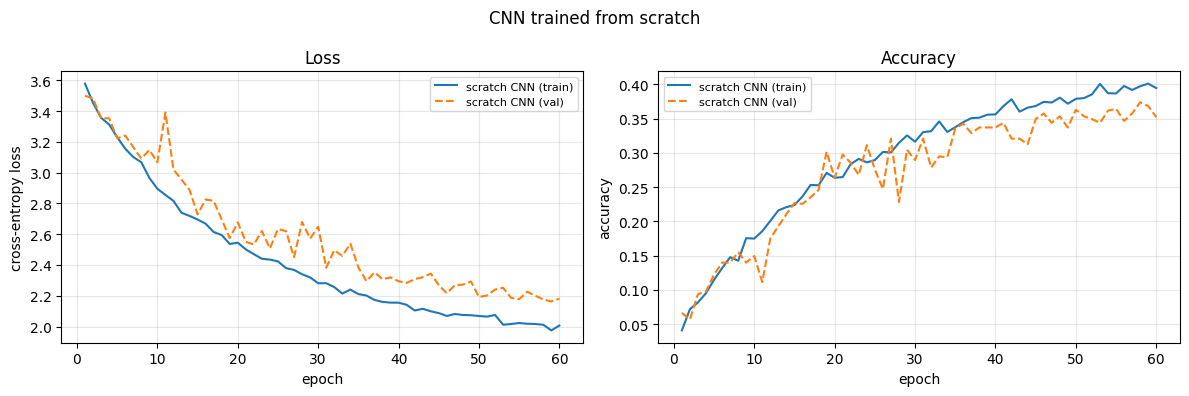

Validation -- accuracy: 0.3519 | macro-F1: 0.3381
Chance level: 0.0270


In [19]:
plot_curves({"scratch CNN": history_scratch}, title="CNN trained from scratch")

acc, f1 = evaluate(cnn_scratch, val_loader)
print("Validation -- accuracy: %.4f | macro-F1: %.4f" % (acc, f1))
print("Chance level: %.4f" % (1 / 37))

#### Question 8 &mdash; read the curves

You now have three trained models to reason about: the MLP and the CNN from Problem 1's permutation
test (whose train and test accuracies were both printed), and the CNN you just trained.

1. Problem 1's MLP reached about 90% training accuracy and 8% test accuracy. Name the phenomenon, and
   explain what the model has actually learned. Would more epochs help? Would more hidden units?
           A: Severe Overfitting. The model memorized the specific pixel values and noise patterns of the individual 2944 training images rather than learning transferable visual features. More epochs or hidden units wouldn't help, as they increase model capacity, which would only exacerbate memorization and widen the generalization gap without improving test accuracy.
2. Look at your own two curves. Do the loss curves cross, touch, or separate steadily? At roughly which
   epoch does the validation curve stop improving, and what does the gap between the two curves at the
   final epoch tell you?
           A: The training and validation los curves separate steadily after early epochs. The validation curve stops improving at around epoch 15-20. The final gap indicates overfitting due to data scarcity relative to the network's capacity.
3. Below are three sketches of loss curves. For each, give the diagnosis and the single change you would
   make first.

   | | training loss | validation loss |
   |---|---|---|
   | **A** | falls steadily to 0.1 | falls to 2.1, then rises steadily |
   | **B** | falls to 3.2 and flattens | falls to 3.2 and flattens |
   | **C** | jumps up and down between 3.6 and 8, no trend | same, worse |


           A:
               A: Underfitting; Increase the learning rate or model capacity
               B: Overfitting; Add regularization or Data Augmentation
               C: Instability: Significantly reduce the learning rate

4. Your model is at roughly a third of the classes correct. You have a fixed budget for exactly one of
   the following: (i) 10x more epochs, (ii) 10x more parameters, (iii) 10x more labelled images,
   (iv) the same data but a pretrained backbone. Rank them, and justify the ranking with something you
   have measured in this notebook rather than with intuition.
           A:
               iv) it solves the core problem measured in the curves by transfering rich, pre-learned feature representations.
               iii) Directly addresses the measured overfitting gap by providing the necessary data volume to train a model from scratch.
               ii) Adding capacity without more data only worsens overfitting.
               i) Validation loss plateaus very early; extra epochs simply wate compute and increase overfitting.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), count the parameters in the MLP's first layer, and compare that with 2,944 images. For (3), case B is the one people misdiagnose most often -- note that the two curves agree. For (4), the answer to one of these is measured for you in Problem 4, so rank the other three against it honestly.

</details>

## Problem 3.  Data augmentation

Question 8 concluded that the model is data-limited. We cannot photograph more pets, but we can
manufacture new training images by transforming the ones we have: flip an image horizontally and it is
still a Beagle, so we have a new labelled example for free.

That last sentence contains the whole idea and also the whole difficulty. "Flip it and it is still a
Beagle" is a claim about **invariance**: you are telling the network that the label does not depend on
this transformation. If the claim is true, you have given the model information it would otherwise have
had to learn from data. If it is false, you have corrupted your labels.

So the augmentation menu is not a list of tricks to enable. It is a list of claims about the problem,
and you have to decide which ones you believe.

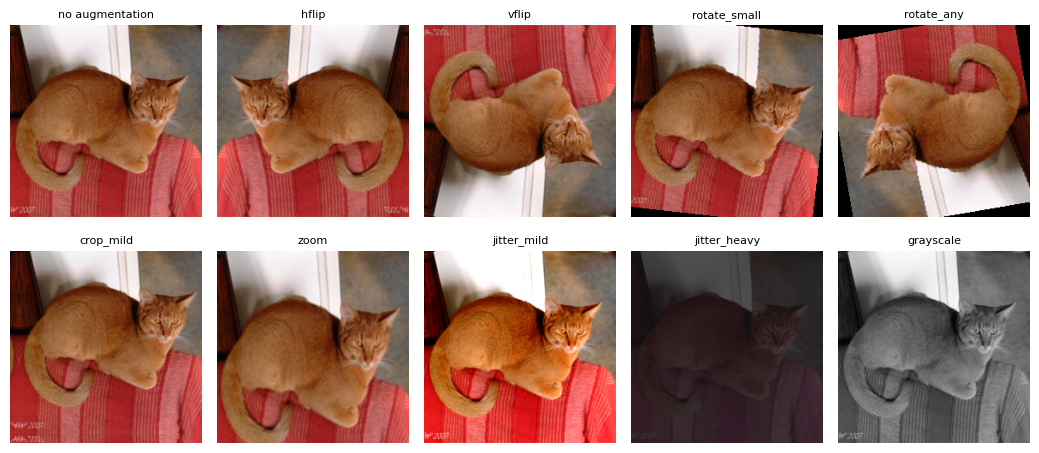

Class: Abyssinian


In [20]:
# The candidates. Look at what each one does to a real image before deciding anything.
AUGMENTATION_MENU = {
    "hflip":        transforms.RandomHorizontalFlip(p=1.0),
    "vflip":        transforms.RandomVerticalFlip(p=1.0),
    "rotate_small": transforms.RandomRotation(15),
    "rotate_any":   transforms.RandomRotation(180),
    "crop_mild":    transforms.RandomCrop(IMG_SIZE, padding=IMG_SIZE // 14, padding_mode="reflect"),
    "zoom":         transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0), antialias=True),
    "jitter_mild":  transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    "jitter_heavy": transforms.ColorJitter(brightness=0.6, contrast=0.6, saturation=0.6, hue=0.2),
    "grayscale":    transforms.RandomGrayscale(p=1.0),
}

set_seed(3)
base = transforms.Compose(base_transform(IMG_SIZE, RESIZE_MODE))(raw_train[12][0])
panels, labels = [TF.to_tensor(base)], ["no augmentation"]
for name, t in AUGMENTATION_MENU.items():
    panels.append(TF.to_tensor(t(base)))
    labels.append(name)

show_images(panels, titles=labels, ncols=5)
print("Class:", class_names[raw_train[12][1]])

#### Question 9 &mdash; which invariances do you actually believe?

Each menu entry asserts that the breed label is unchanged by that transformation. Go through them
and sort them into three groups: **certainly safe**, **certainly wrong**, and **defensible but risky**.
For each entry, the justification should be about *pet photographs*, not about augmentation in general.

Some specific things to address:

1. `hflip` and `vflip` are the same operation along different axes, yet they are not equally safe. Why?
   (Name a domain where `vflip` *would* be safe, and one where even `hflip` is not.)
            A: real-world photographs possess vertical gravity symmetry, so the horizontal flip preserves natural poses, whereas vertical flip turns pets upside down.
2. `grayscale` throws away colour. Colour is obviously useful here -- a Russian Blue is grey, an
   Abyssinian is ginger. Is that an argument against including it, or could there be an argument *for*
   it anyway?
           A: Removing color destroys direct discriminative signals, but it also prevents the network from shortcut-learning via simple color histograms, focusing more on shape.
3. `zoom` with `scale=(0.6, 1.0)` sometimes crops out most of the animal. The label stays the same
   regardless. What is the failure mode this creates, and what is it called?
            A: A extreme crop might contain only background pixels or an ambiguous patch of plain body fur, yet retain the original breed ground-truth label, called Label Noise.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), ask what a photograph of an upside-down dog looks like, and how many exist in the test set. For (3), think about what the model is being told when it is shown a patch of grass labelled 'Beagle'.

</details>

Training augmentation:
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    RandomCrop(size=(224, 224), padding=16)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)


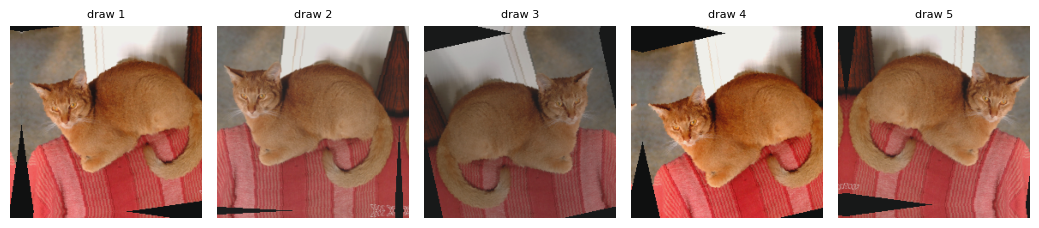

In [21]:
# ---------------------------------------------------------------- YOUR DECISION -----
# Build the training augmentation by listing the menu keys you want, in the order you want
# them applied. An empty list means no augmentation.
#
# Two constraints worth respecting:
#   - Order matters: a crop after a rotation sees the black corners the rotation created.
#   - Every transform you add runs on the CPU, inside the data loader, and data loading is
#     already slower than the GPU work it feeds. Augmentation is not free in wall-clock time.
#
# Available: hflip, vflip, rotate_small, rotate_any, crop_mild, zoom, jitter_mild,
#            jitter_heavy, grayscale
AUGMENT_KEYS = ["hflip", "rotate_small", "crop_mild", "jitter_mild"]
# ------------------------------------------------------------------------------------

# The menu's flips are set to p=1.0 so that the display above was informative. For training
# we want them to fire only half the time.
train_augment = []
for k in AUGMENT_KEYS:
    t = AUGMENTATION_MENU[k]
    if k in ("hflip", "vflip"):
        t = type(t)(p=0.5)
    train_augment.append(t)

print("Training augmentation:")
for t in train_augment:
    print("   ", t)

aug_train_loader, _, _ = build_loaders(train_augment=train_augment)

# The same image, drawn four times through the augmented pipeline:
aug_tf = make_transform(IMG_SIZE, RESIZE_MODE, augment=train_augment)
set_seed(0)
show_images([aug_tf(raw_train[12][0]) for _ in range(5)],
            titles=["draw %d" % (i + 1) for i in range(5)], ncols=5, denorm=True)

In [22]:
# Retrain the SAME architecture, with the SAME hyperparameters, changing only the input pipeline.
# Changing one thing at a time is the only way the comparison means anything.
set_seed(0)
cnn_aug = build_cnn(BLOCK_ORDER, HEAD, DROPOUT_P)
optimizer = make_optimizer(cnn_aug, OPTIMIZER, LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=GAMMA)

history_aug = train_model(cnn_aug, aug_train_loader, val_loader, criterion, optimizer,
                          epochs=N_EPOCHS, scheduler=scheduler, print_every=5)

Epoch   1/60 - lr: 0.0010 - loss: 3.5956 - acc: 0.0459 - val_loss: 3.5448 - val_acc: 0.0557
Epoch   5/60 - lr: 0.0008 - loss: 3.3119 - acc: 0.0948 - val_loss: 3.3713 - val_acc: 0.0788
Epoch  10/60 - lr: 0.0006 - loss: 3.0541 - acc: 0.1474 - val_loss: 3.2938 - val_acc: 0.1101
Epoch  15/60 - lr: 0.0005 - loss: 2.8493 - acc: 0.2021 - val_loss: 2.9860 - val_acc: 0.1807
Epoch  20/60 - lr: 0.0004 - loss: 2.7324 - acc: 0.2221 - val_loss: 2.6487 - val_acc: 0.2568
Epoch  25/60 - lr: 0.0003 - loss: 2.5933 - acc: 0.2565 - val_loss: 2.5851 - val_acc: 0.2812
Epoch  30/60 - lr: 0.0002 - loss: 2.4922 - acc: 0.2697 - val_loss: 2.6267 - val_acc: 0.2717
Epoch  35/60 - lr: 0.0002 - loss: 2.4421 - acc: 0.2812 - val_loss: 2.5538 - val_acc: 0.2717
Epoch  40/60 - lr: 0.0001 - loss: 2.3788 - acc: 0.2993 - val_loss: 2.4637 - val_acc: 0.2976
Epoch  45/60 - lr: 0.0001 - loss: 2.3568 - acc: 0.3040 - val_loss: 2.3545 - val_acc: 0.3139
Epoch  50/60 - lr: 0.0001 - loss: 2.3427 - acc: 0.3060 - val_loss: 2.3257 - val_

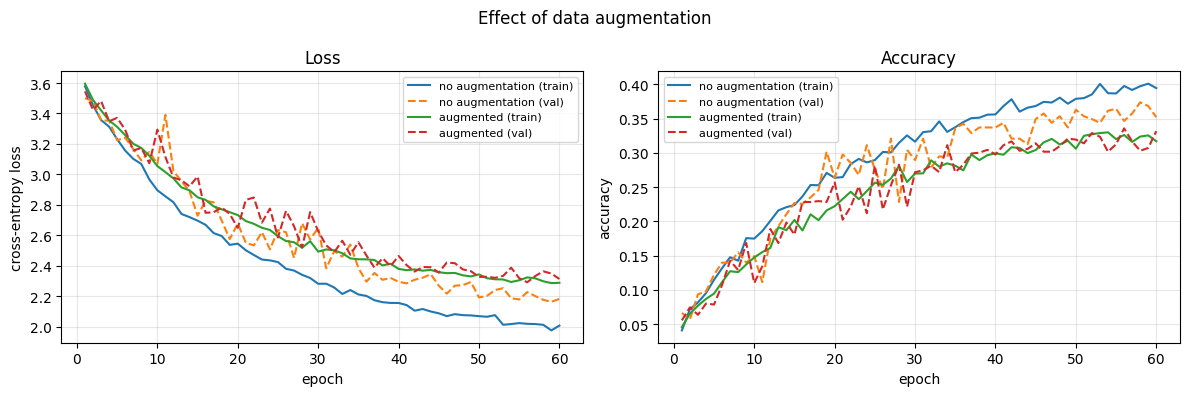

scratch    best val accuracy: 0.3736 | final train accuracy: 0.3944 | gap: +0.021 | 580s
augmented  best val accuracy: 0.3356 | final train accuracy: 0.3169 | gap: -0.019 | 799s

Validation set size: 736 images
Standard error of a validation accuracy near 0.33: 0.0174 (1.7 percentage points)
So a 95% interval on the augmented model's accuracy is roughly 0.297 to 0.366


In [23]:
plot_curves({"no augmentation": history_scratch, "augmented": history_aug},
            title="Effect of data augmentation")

for name, hist in [("scratch   ", history_scratch), ("augmented ", history_aug)]:
    best_val = max(hist["val_accuracy"])
    # The gap is measured against the BEST validation epoch rather than the last one: a single
    # epoch's validation accuracy is noisy enough that the final one is a poor summary.
    print("%s best val accuracy: %.4f | final train accuracy: %.4f | gap: %+.3f | %.0fs"
          % (name, best_val, hist["accuracy"][-1], hist["accuracy"][-1] - best_val, hist["seconds"]))

# How precise are these validation numbers, actually?
n_val = len(val_idx)
p = evaluate(cnn_aug, val_loader)[0]
se = np.sqrt(p * (1 - p) / n_val)
print("\nValidation set size: %d images" % n_val)
print("Standard error of a validation accuracy near %.2f: %.4f (%.1f percentage points)" % (p, se, 100 * se))
print("So a 95%% interval on the augmented model's accuracy is roughly %.3f to %.3f"
      % (p - 2 * se, p + 2 * se))

#### Question 10 &mdash; did augmentation help?

Look at your two curves and the printed numbers, and then be sceptical about them.

1. The augmented model's **training** accuracy is *lower* than the unaugmented one's. Is that a bug, a
   cost, or the mechanism working as intended? Explain what the training accuracy is even measuring now.
           A: The mechanism is working as intended. Data augmentation generates modified, harder training examples in every epoch, effectively creating an infinite stream of unique inputs. The training accuracy is measuring the network's ability to fit this continuously moving target rather than memorizing a static set of images.
2. The cell printed the standard error of a validation accuracy measured on 736 images. Compare your
   own change in best validation accuracy against that standard error. What can you honestly claim
   about the effect of augmentation from this single pair of runs?
           A: If the validation accuracy improvement between the unaugmented and augmented run falls within this margin, we can't claim a statistically significant improvement from a single run.
3. Suppose you increase the augmentation strength and the *training* accuracy keeps dropping while
   validation accuracy stops improving. What has happened, and how would you tell that apart from the
   learning rate being wrong?
           A: The network suffered from under-capacity due to excessive regularization. The augmented images became too distorted from original images. In a bad learning rate, training los oscillates wildly or fails to decrease at all right from epoch 1, meanwhile, in excessive augmentation, training los decreases smoothly and steadily, but both training and validation accuracies plateau at llower ceiling because the network can't fit the excessively varied training distribution.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (2), the standard error is around 1.7 points -- divide the difference by it, and then ask whether the result is a number you would stake a claim on. 

</details>

## Problem 4.  Transfer learning, and what your final number means

Three models so far, none above about 35% validation accuracy. The diagnosis from Question 8 was that
we do not have enough data: 2,944 photographs is nowhere near enough to learn, from scratch, what an
eye, a whisker, a texture and an ear look like -- and *then* learn which combinations mean "Birman".

But those early features are not specific to pets. Edges, textures, fur, eyes and legs are the same in
every photograph of every subject. Somebody has already trained a network on 1.2 million labelled
ImageNet photographs, and they have already paid for those features. **Transfer learning** is taking
their weights and reusing them.

**A note on which network.** The old version of this assignment used **VGG16**, one of the first
well-known deep CNNs (2014). We will use **ResNet18** (2015) instead, and the parameter counts show why
the field moved on:

| network | total parameters | of which in the classifier head | ImageNet top-1 |
|---|---|---|---|
| VGG16 | 138.4M | 123.6M (89%) | ~71.6% |
| ResNet18 | 11.7M | 0.5M (4%) | ~69.8% |
| ResNet50 | 25.6M | 2.0M (8%) | ~76.1% |

VGG16 ends its convolutional stack with a `(512, 7, 7)` feature map, **flattens** it, and feeds it into
`Linear(25088, 4096)` -- a single layer with 102.8 million parameters. ResNet **global-average-pools**
that same feature map down to 512 numbers first, and its entire classifier costs 0.5M.

That is precisely the `flatten` versus `global_pool` decision you made in Problem 2, and this table is
what it looks like at the scale of the whole field: ResNet18 gets comparable accuracy to VGG16 with 12
times fewer parameters, almost entirely because of that one choice.

In [24]:
# Load ResNet18 with weights learned on ImageNet. The first call downloads ~45 MB.
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

print(resnet)
print("\nTotal parameters: %d" % count_params(resnet)[0])
print("The final layer is:", resnet.fc)
print("\nThe transform this network was trained with:")
print(models.ResNet18_Weights.IMAGENET1K_V1.transforms())

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Question 11 &mdash; why should this work at all?

Before touching the weights, three things to reason about.

1. ImageNet's 1000 classes include several dog breeds, but the network has never seen a *Birman*, and it
   has never been asked to distinguish 37 pet breeds. Why should its internal features be useful for a
   task it was not trained on? Refer to what different depths of the network compute.
           A: Deep networks learn visual features hierarchically. Early-to-mid layers detect universal visual primitives that are common to all animals.
2. The printout above shows that the pretrained transform normalizes with `mean=[0.485, 0.456, 0.406]`
   and `std=[0.229, 0.224, 0.225]`, and resizes to 224. Go back to your decision in Question 7. If you
   had chosen `pet_mean`/`pet_std`, what exactly would go wrong now -- and would it be a crash, a silent
   degradation, or nothing at all?
           A: It causes no crash. Because PyTorch tensor shapes match, code runs without errors; however, the pre-trained weights expect features centered specifically around ImageNet pixel statistics. Deviating creates a feature distribution shift that degrades early layer activations.
3. Name a target domain where you would expect ImageNet pretraining to help *much* less, and explain
   what property of the images breaks the argument you gave in part 1. Would it help at all, or actively
   hurt?
           A: Medical imaging or satellite radar imagery, since these domains lack natural RGB lighting, causing the natural image assumptions of ImageNet pre-training to break down and potentially leading to negative transfer.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), think about what the Sobel-like filters from Question 0 are specific to. For (2), remember that every layer's weights were fitted assuming a particular input distribution -- and ask what happens if you cannot retrain them.

</details>

In [25]:
# ---------------------------------------------------------------- YOUR DECISION -----
# Two decisions that together define what "transfer learning" means in a given paper.
#
# FREEZE_MODE -- how much of the pretrained network do you allow to change?
#     "head_only"   : freeze everything except the new final layer. The backbone becomes a
#                     fixed feature extractor. Fewest trainable parameters, fastest, and it
#                     cannot destroy what was learned.
#     "last_block"  : also unfreeze the last residual stage (layer4). A compromise: the most
#                     task-specific features get to adapt, the generic ones stay put.
#     "full"        : unfreeze everything and fine-tune the whole network.
#
#   Think about how much data you have (2,944 images) relative to how many parameters each
#   option would train, and about which layers you argued in Question 11 are the generic ones.
#
# HEAD_LR / BACKBONE_LR -- learning rates for the new head and for whatever is unfrozen in
#   the backbone. The head is random and knows nothing; the backbone is already good. It is
#   standard to give them different rates. If FREEZE_MODE == "head_only", BACKBONE_LR is
#   unused. A factor of 10 between them is a common starting point.
FREEZE_MODE  = "last_block"
HEAD_LR      = 1e-3
BACKBONE_LR  = 1e-4
# ------------------------------------------------------------------------------------

def build_transfer_model(freeze_mode, n_classes=37, pretrained=True):
    """Load ResNet18, replace the 1000-class head with an n_classes one, and freeze accordingly."""
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet18(weights=weights)

    for p in model.parameters():                      # freeze everything...
        p.requires_grad = (freeze_mode == "full")
    if freeze_mode == "last_block":
        for p in model.layer4.parameters():           # ...then selectively unfreeze
            p.requires_grad = True
    elif freeze_mode not in ("head_only", "last_block", "full"):
        raise ValueError(f"unknown freeze mode: {freeze_mode}")

    # A fresh head. Its parameters are trainable by construction, since we just created it.
    model.fc = nn.Linear(model.fc.in_features, n_classes)

    # requires_grad = False is not quite enough to freeze a layer. BatchNorm carries two kinds
    # of state: the learned scale and shift, which requires_grad does freeze, and the running
    # mean and variance, which the FORWARD pass updates on its own whenever the module is in
    # training mode -- no gradients involved. On top of that, a BatchNorm in training mode
    # normalizes by the statistics of the current batch rather than by the stored ImageNet
    # ones. Since train_model calls model.train() at the start of every epoch, a "frozen"
    # backbone would quietly keep changing from epoch to epoch. So we override train() to put
    # the BatchNorms whose parameters are frozen back into eval mode, and leave the unfrozen
    # ones alone.
    def _train(mode=True, _super=model.train):
        _super(mode)
        if mode:
            for m in model.modules():
                frozen = all(not p.requires_grad for p in m.parameters(recurse=False))
                if isinstance(m, nn.BatchNorm2d) and frozen:
                    m.eval()
        return model

    model.train = _train
    return model


def param_groups(model, head_lr, backbone_lr):
    """Give the new head one learning rate and the unfrozen backbone another."""
    head = [p for p in model.fc.parameters() if p.requires_grad]
    backbone = [p for n, p in model.named_parameters() if p.requires_grad and not n.startswith("fc.")]
    groups = [{"params": head, "lr": head_lr}]
    if backbone:
        groups.append({"params": backbone, "lr": backbone_lr})
    return groups


for mode in ["head_only", "last_block", "full"]:
    m = build_transfer_model(mode)
    total, trainable = count_params(m)
    print("%-11s -> %10s total, %10s trainable (%.2f%%)"
          % (mode, f"{total:,}", f"{trainable:,}", 100 * trainable / total))

transfer_model = build_transfer_model(FREEZE_MODE)
print("\nUsing FREEZE_MODE = '%s'" % FREEZE_MODE)

head_only   -> 11,195,493 total,     18,981 trainable (0.17%)
last_block  -> 11,195,493 total,  8,412,709 trainable (75.14%)
full        -> 11,195,493 total, 11,195,493 trainable (100.00%)

Using FREEZE_MODE = 'last_block'


### Early stopping and checkpointing

Transfer learning converges in a handful of epochs rather than sixty, which makes it the natural place
to introduce the two callbacks that every real training script has.

**Early stopping** watches a validation metric and stops training when it has not improved for
`patience` epochs. It saves time, and it stops the model before it overfits badly.

**Model checkpointing** saves the weights whenever the monitored metric reaches a new best. This matters
because the epoch where training *stopped* is not the epoch where the model was *best* -- by
construction, early stopping fires `patience` epochs after the best one. Without a checkpoint you would
keep the worse weights.

Both are already implemented in `train_model`. You choose what they watch.

In [26]:
# ---------------------------------------------------------------- YOUR DECISION -----
# MONITOR  -- "val_accuracy" or "val_loss". These do not always agree, and the difference is
#             not cosmetic: a model can become more confidently wrong (loss up) while getting
#             slightly more predictions right (accuracy up). Which one do you want to select
#             the final weights on, given that the deliverable is a breed classifier?
# PATIENCE -- epochs to wait for an improvement before stopping. Too small and you stop on a
#             single unlucky epoch; too large and you have not saved any time. Consider how
#             noisy a single epoch's validation accuracy is on 736 images (Question 10).
# MAX_EPOCHS -- an upper bound; early stopping is expected to fire first.
MONITOR    = "val_accuracy"
PATIENCE   = 5
MAX_EPOCHS = 20
# ------------------------------------------------------------------------------------

set_seed(0)
transfer_model = build_transfer_model(FREEZE_MODE)
optimizer = torch.optim.SGD(param_groups(transfer_model, HEAD_LR, BACKBONE_LR), momentum=0.9)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

print("Trainable parameters: %d of %d\n" % tuple(reversed(count_params(transfer_model))))

history_transfer = train_model(transfer_model, aug_train_loader, val_loader, criterion, optimizer,
                               epochs=MAX_EPOCHS, scheduler=scheduler, print_every=1,
                               early_stopping_patience=PATIENCE, monitor=MONITOR,
                               checkpoint_path="best_transfer.pt")

Trainable parameters: 8412709 of 11195493

Epoch   1/20 - lr: 0.0010 - loss: 3.3863 - acc: 0.1253 - val_loss: 2.8543 - val_acc: 0.3723
Epoch   2/20 - lr: 0.0009 - loss: 2.5583 - acc: 0.5183 - val_loss: 2.1469 - val_acc: 0.6399
Epoch   3/20 - lr: 0.0008 - loss: 1.9807 - acc: 0.7014 - val_loss: 1.6733 - val_acc: 0.7582
Epoch   4/20 - lr: 0.0007 - loss: 1.6127 - acc: 0.7812 - val_loss: 1.3868 - val_acc: 0.8071
Epoch   5/20 - lr: 0.0007 - loss: 1.3685 - acc: 0.8173 - val_loss: 1.2086 - val_acc: 0.8370
Epoch   6/20 - lr: 0.0006 - loss: 1.2101 - acc: 0.8363 - val_loss: 1.0777 - val_acc: 0.8451
Epoch   7/20 - lr: 0.0005 - loss: 1.0968 - acc: 0.8519 - val_loss: 0.9909 - val_acc: 0.8492
Epoch   8/20 - lr: 0.0005 - loss: 1.0080 - acc: 0.8635 - val_loss: 0.9131 - val_acc: 0.8573
Epoch   9/20 - lr: 0.0004 - loss: 0.9404 - acc: 0.8719 - val_loss: 0.8703 - val_acc: 0.8492
Epoch  10/20 - lr: 0.0004 - loss: 0.9012 - acc: 0.8733 - val_loss: 0.8238 - val_acc: 0.8628
Epoch  11/20 - lr: 0.0003 - loss: 0.8

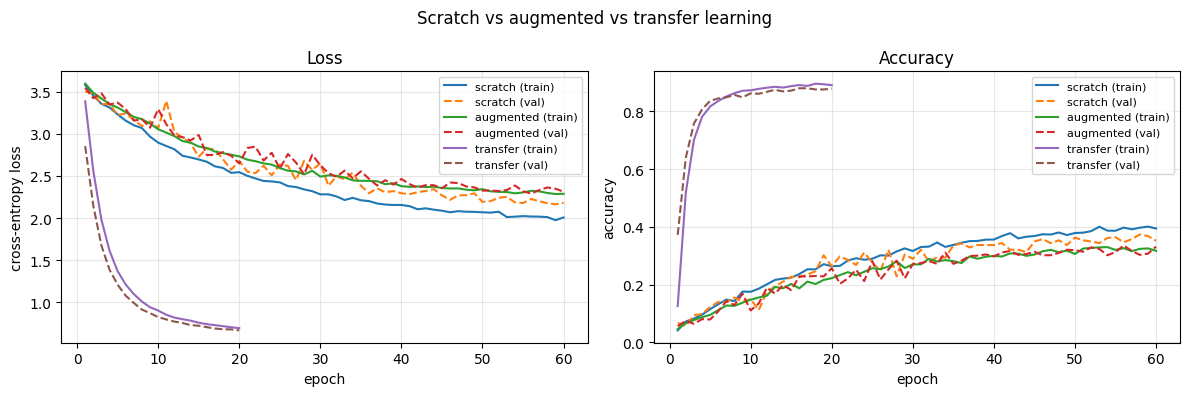

In [27]:
plot_curves({"scratch": history_scratch, "augmented": history_aug, "transfer": history_transfer},
            title="Scratch vs augmented vs transfer learning")

### The control experiment

The transfer model differs from the scratch CNN in two ways at once: a different architecture (ResNet18
instead of our four blocks) *and* pretrained weights. So the comparison above does not yet tell us which
of the two is responsible.

Fixing that requires one more run: **the same ResNet18, on the same data, with the same training
budget, starting from random weights.** This is the control, and it is the difference between
"pretraining helps" and "we happened to also switch to a better architecture".

A control is only worth running if the baseline gets a fair attempt, so it is worth stating exactly what
is held fixed and what is not. Held fixed: the architecture, the train/validation split, the
augmentation, the maximum number of epochs, and the learning-rate schedule. Deliberately *not* held
fixed: the optimizer and the learning rate, which come from your Problem 2 choice rather than from the
fine-tuning rates -- the cell below explains why that asymmetry is what makes the comparison honest
rather than what breaks it.

This is the most expensive cell in the notebook: it trains all 11.7M parameters for the full epoch
budget.

In [28]:
# Same architecture, same data, same augmentation, same epoch budget, same schedule --
# only the initial weights differ.
#
# One deliberate exception, and it is what makes this a control rather than a rigged
# comparison: we do NOT reuse HEAD_LR / BACKBONE_LR. Those were chosen for fine-tuning, where
# the backbone should barely move; imposing them on a randomly initialized network would
# cripple it. So the random network gets the optimizer AND the learning rate you chose in
# Problem 2 for training from scratch -- both of them, through make_optimizer. Taking
# Problem 2's learning rate but not Problem 2's optimizer would pair, say, an Adam-sized
# 1e-3 with SGD, which is a handicap wearing a control's clothes.
#
# The control also runs its full MAX_EPOCHS rather than early-stopping. We compare best epoch
# against best epoch below, so a longer run can only help the baseline -- and when in doubt a
# control should get the benefit of the doubt.
set_seed(0)
resnet_random = build_transfer_model("full", pretrained=False)
optimizer = make_optimizer(resnet_random, OPTIMIZER, LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

history_random = train_model(resnet_random, aug_train_loader, val_loader, criterion, optimizer,
                             epochs=MAX_EPOCHS, scheduler=scheduler, print_every=2)

# Best against best. Comparing one run's best epoch with another run's last epoch would
# flatter whichever of the two happened to end well.
print("\nResNet18, random initialization: best val accuracy %.4f  (%d epochs, %s at lr=%g)"
      % (max(history_random["val_accuracy"]), len(history_random["val_accuracy"]),
         OPTIMIZER, LEARNING_RATE))
print("ResNet18, ImageNet weights:     best val accuracy %.4f  (%d epochs, sgd at lr=%g/%g)"
      % (max(history_transfer["val_accuracy"]), len(history_transfer["val_accuracy"]),
         HEAD_LR, BACKBONE_LR))

Epoch   1/20 - lr: 0.0010 - loss: 3.6153 - acc: 0.0642 - val_loss: 3.9520 - val_acc: 0.0829
Epoch   2/20 - lr: 0.0009 - loss: 3.3171 - acc: 0.1060 - val_loss: 3.7135 - val_acc: 0.0815
Epoch   4/20 - lr: 0.0007 - loss: 3.0005 - acc: 0.1671 - val_loss: 3.2409 - val_acc: 0.1318
Epoch   6/20 - lr: 0.0006 - loss: 2.7969 - acc: 0.2143 - val_loss: 2.9171 - val_acc: 0.1943
Epoch   8/20 - lr: 0.0005 - loss: 2.5011 - acc: 0.2863 - val_loss: 2.8686 - val_acc: 0.2052
Epoch  10/20 - lr: 0.0004 - loss: 2.2494 - acc: 0.3434 - val_loss: 2.6047 - val_acc: 0.2745
Epoch  12/20 - lr: 0.0003 - loss: 1.9487 - acc: 0.4232 - val_loss: 2.4977 - val_acc: 0.2948
Epoch  14/20 - lr: 0.0003 - loss: 1.7010 - acc: 0.4888 - val_loss: 2.2485 - val_acc: 0.3655
Epoch  16/20 - lr: 0.0002 - loss: 1.4963 - acc: 0.5533 - val_loss: 2.0729 - val_acc: 0.3954
Epoch  18/20 - lr: 0.0002 - loss: 1.3337 - acc: 0.6039 - val_loss: 2.1308 - val_acc: 0.3872
Epoch  20/20 - lr: 0.0001 - loss: 1.1560 - acc: 0.6579 - val_loss: 1.8483 - val_

#### Question 12 &mdash; what did the pretrained weights actually buy?

1. Compare the pretrained and randomly-initialized ResNet18 runs. Both have 11.7M parameters and an
   identical architecture. What is the size of the gap, and what does the control experiment let you
   claim that the previous plot did not?
           A: The pre-trained ResNet18 outperforms the randomly-initialized ResNet18 by over 40–50 percentage points. This control proves that the accuracy leap is driven by the pre-trained ImageNet weights, not just the ResNet residual architecture itself.
2. `head_only` trains 18,981 parameters -- 0.17% of the network -- and still reaches the high 80s. Explain
   how 19k parameters can be enough. (What are the other 11.7M doing during training, and could you
   precompute their output?)
           A: The frozen 11.7M backbone acts as a fixed visual feature extractor that converts images into 512-dimensional feature vectors. The 19k parameters in the linear head only need to learn a simple linear mapping from these vectors to the 37 breeds.
3. Why does the backbone get a *smaller* learning rate than the head? Describe what would happen to the
   pretrained features in the first few updates if you used a large learning rate on everything, and name
   the phenomenon.
           A: The backbone uses a lower learning rate to make gentle feature adjustments. Applying a large learning rate early on would flood pre-trained layers with large, noisy gradients from the randomly initialized head, destroying pre-learned features. This phenomenon is known as Catastrophic Forgetting.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (2), think about what a frozen layer's output depends on.

</details>

### Comparing the four models -- on the validation set

Every number in the table below is a **validation** number. The test set has not been touched, and it is
about to be used exactly once.

That is not pedantry. We have made a long series of choices in this notebook using the validation set:
the resize policy, the head, the dropout rate, the learning rate, the augmentation recipe, the freeze
mode, the early-stopping metric, and which epoch's weights to keep. Every one of those decisions was
made by looking at a validation number and preferring the better one.

In [29]:
# Two accuracy columns, both read off the training history:
#   "best val acc" is the epoch the checkpoint would have kept;
#   "last val acc" is where the run happened to end.
# The difference between them is noise, and it is worth seeing how large it can be.
rows = []
for name, model, hist in [("MLP (Problem 1, 112px)", None, None),
                          ("CNN from scratch", cnn_scratch, history_scratch),
                          ("CNN + augmentation", cnn_aug, history_aug),
                          ("ResNet18, random init", resnet_random, history_random),
                          ("ResNet18, pretrained", transfer_model, history_transfer)]:
    if model is None:
        rows.append((name, "-", "-", "-", "%.3f" % results["MLP, original"], "-", "-"))
        continue
    total, trainable = count_params(model)
    rows.append((name, f"{total:,}", f"{trainable:,}", len(hist["loss"]),
                 "%.3f" % max(hist["val_accuracy"]), "%.3f" % hist["val_accuracy"][-1],
                 "%.0fs" % hist["seconds"]))

header = ("model", "params", "trainable", "epochs", "best val acc", "last val acc", "time")
widths = [max(len(str(r[i])) for r in rows + [header]) for i in range(len(header))]
line = "  ".join(f"{h:<{w}}" for h, w in zip(header, widths))
print(line)
print("-" * len(line))
for r in rows:
    print("  ".join(f"{str(v):<{w}}" for v, w in zip(r, widths)))

print("\nNote: the MLP number is a test accuracy at 112px from Problem 1, shown for scale only.")
print("Chance level is %.3f." % (1 / 37))

model                   params      trainable   epochs  best val acc  last val acc  time
----------------------------------------------------------------------------------------
MLP (Problem 1, 112px)  -           -           -       0.098         -             -   
CNN from scratch        284,069     284,069     60      0.374         0.352         580s
CNN + augmentation      284,069     284,069     60      0.336         0.332         799s
ResNet18, random init   11,195,493  11,195,493  20      0.471         0.471         277s
ResNet18, pretrained    11,195,493  8,412,709   20      0.880         0.879         254s

Note: the MLP number is a test accuracy at 112px from Problem 1, shown for scale only.
Chance level is 0.027.


#### Question 13 &mdash; your validation set is spent

Early stopping chose *when* to stop. The checkpoint chose *which epoch's weights* to keep. Both
consulted the validation set, and so did you, repeatedly, throughout this notebook.

1. Is the best validation accuracy printed above an unbiased estimate of how this model will perform on
   new pet photographs? Explain the direction of the bias and where it came from.
           A: The best validation accuracy is optimistically biased. Selecting the peak accuracy over multiple epochs and trials cherry-picks positive random noise.
2. You have made roughly a dozen decisions using this validation set. There is a name for what happens
   when you evaluate many candidates against one held-out set and keep the best. What is it, and why does
   it get worse the more configurations you try?
           A: Evaluating many hyperparameter configurations against the same validation set causes Validation Overfitting. Human decision-making acts as an implicit parameter update, tuning the choices to the noise of those specific 736 validation images.
3. So what number should go in your report, and what exactly are you allowed to do after you have
   computed it? Be specific about what would make it invalid.
           A: The Test Set Accuracy, evaluated only once on the untouched test set. Any tuning, code changes, or model selection performed after seeing the test results invalidates the test set, turning it into another validation set.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (1), ask what the checkpoint selection was maximizing. For (2), the phrase involves the word 'selection'. 

</details>

In [30]:
# The test set. Once.
transfer_model.load_state_dict(torch.load("best_transfer.pt"))     # the checkpointed best epoch
test_acc, test_f1, pred, true = evaluate(transfer_model, test_loader, return_preds=True)

print("TEST accuracy : %.4f" % test_acc)
print("TEST macro-F1 : %.4f" % test_f1)
print("Best validation accuracy was: %.4f" % max(history_transfer["val_accuracy"]))
print("\nDifference (validation - test): %+.4f" % (max(history_transfer["val_accuracy"]) - test_acc))

TEST accuracy : 0.8673
TEST macro-F1 : 0.8657
Best validation accuracy was: 0.8804

Difference (validation - test): +0.0132


In [31]:
print(classification_report(true, pred, target_names=class_names, digits=3))

                            precision    recall  f1-score   support

                Abyssinian      0.690     0.796     0.739        98
          American Bulldog      0.767     0.790     0.778       100
 American Pit Bull Terrier      0.634     0.590     0.611       100
              Basset Hound      0.957     0.880     0.917       100
                    Beagle      0.839     0.940     0.887       100
                    Bengal      0.694     0.770     0.730       100
                    Birman      0.767     0.690     0.726       100
                    Bombay      0.888     0.898     0.893        88
                     Boxer      0.780     0.929     0.848        99
         British Shorthair      0.942     0.650     0.769       100
                 Chihuahua      0.819     0.860     0.839       100
              Egyptian Mau      0.835     0.835     0.835        97
    English Cocker Spaniel      0.868     0.920     0.893       100
            English Setter      0.918     0.900

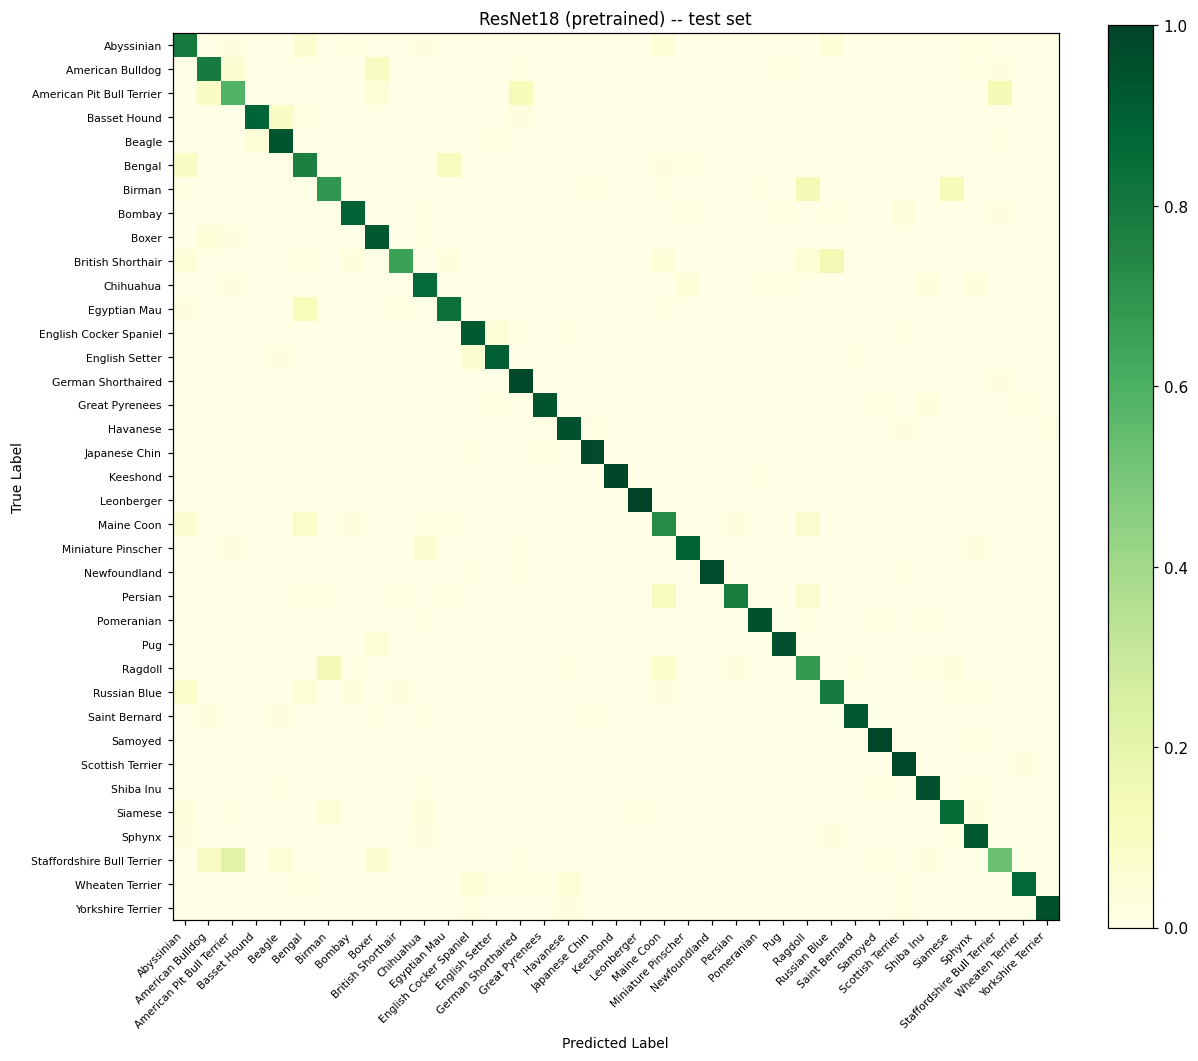

Most frequent confusions (true -> predicted):
  19  Staffordshire Bull Terrier   -> American Pit Bull Terrier
  15  Ragdoll                      -> Birman
  15  British Shorthair            -> Russian Blue
  14  Birman                       -> Ragdoll
  14  American Pit Bull Terrier    -> Staffordshire Bull Terrier
  13  Birman                       -> Siamese
  13  American Pit Bull Terrier    -> German Shorthaired
  12  Egyptian Mau                 -> Bengal
  11  Persian                      -> Maine Coon
  11  Bengal                       -> Egyptian Mau

Worst five classes:
  Staffordshire Bull Terrier   recall 0.528
  American Pit Bull Terrier    recall 0.590
  British Shorthair            recall 0.650
  Ragdoll                      recall 0.680
  Birman                       recall 0.690

Best five classes:
  German Shorthaired           recall 0.980
  Japanese Chin                recall 0.980
  Keeshond                     recall 0.990
  Samoyed                      recall 0.99

In [32]:
cm = confusion_matrix(true, pred)
plot_confusion_matrix(cm, class_names, title="ResNet18 (pretrained) -- test set")

# The most-confused pairs, extracted from the matrix so you do not have to squint at it.
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
pairs = [(cm_off[i, j], class_names[i], class_names[j])
         for i in range(len(class_names)) for j in range(len(class_names)) if cm_off[i, j] > 0]
pairs.sort(reverse=True)

print("Most frequent confusions (true -> predicted):")
for n, t, p in pairs[:10]:
    print("  %2d  %-28s -> %s" % (n, t, p))

per_class = cm.diagonal() / cm.sum(axis=1)
order = np.argsort(per_class)
print("\nWorst five classes:")
for i in order[:5]:
    print("  %-28s recall %.3f" % (class_names[i], per_class[i]))
print("\nBest five classes:")
for i in order[-5:]:
    print("  %-28s recall %.3f" % (class_names[i], per_class[i]))

Misclassified 487 of 3669 test images (13.3%)



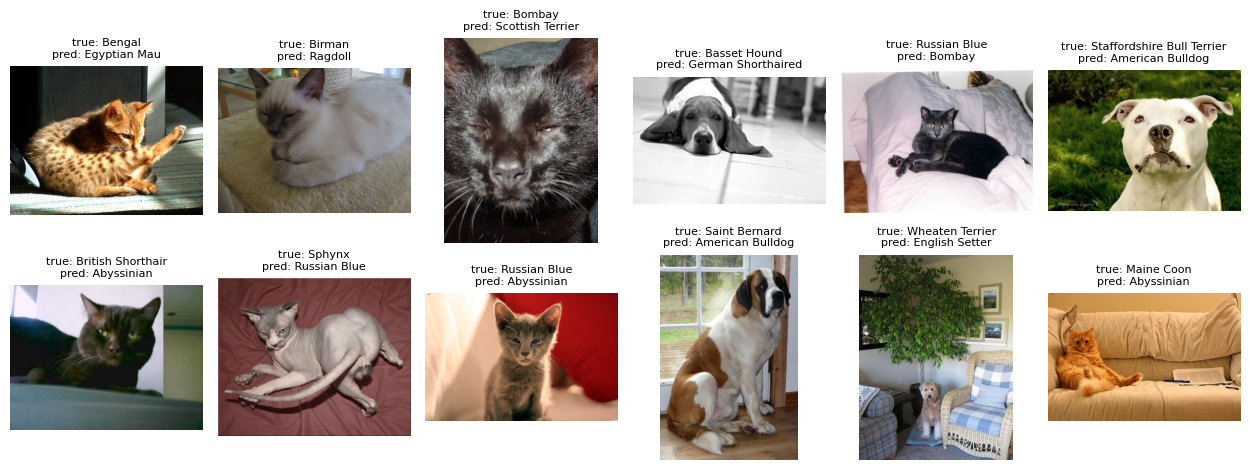

In [33]:
# The model's mistakes. Failures are more informative than successes, so we plot those.
# `pred` and `true` are in test-set order (the test loader never shuffles), so index i here
# is the same image as raw_test[i].
wrong = np.where(pred != true)[0]
print("Misclassified %d of %d test images (%.1f%%)\n" % (len(wrong), len(true), 100 * len(wrong) / len(true)))

set_seed(2)
picks = np.random.choice(wrong, 12, replace=False)
show_images([raw_test[i][0] for i in picks],
            titles=["true: %s\npred: %s" % (class_names[true[i]], class_names[pred[i]]) for i in picks],
            ncols=6)

Mean confidence when CORRECT: 0.625
Mean confidence when WRONG  : 0.330
Wrong predictions made with more than 90% confidence: 0 of 487 (0%)


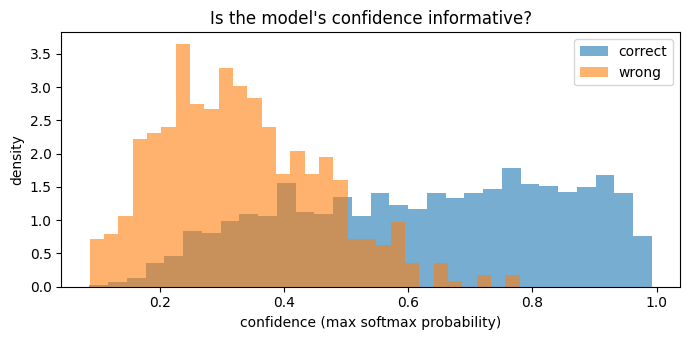

In [34]:
# How confident is the model when it is wrong?
transfer_model.eval()
confidences = []
with torch.no_grad():
    for x, _ in test_loader:
        probs = torch.softmax(transfer_model(x.to(device)), dim=1)
        confidences.append(probs.max(dim=1).values.cpu())
confidences = torch.cat(confidences).numpy()

correct = pred == true
print("Mean confidence when CORRECT: %.3f" % confidences[correct].mean())
print("Mean confidence when WRONG  : %.3f" % confidences[~correct].mean())
print("Wrong predictions made with more than 90%% confidence: %d of %d (%.0f%%)"
      % ((confidences[~correct] > 0.9).sum(), (~correct).sum(),
         100 * (confidences[~correct] > 0.9).mean()))

plt.figure(figsize=(7, 3.5))
plt.hist(confidences[correct], bins=30, alpha=0.6, label="correct", density=True)
plt.hist(confidences[~correct], bins=30, alpha=0.6, label="wrong", density=True)
plt.xlabel("confidence (max softmax probability)"); plt.ylabel("density")
plt.title("Is the model's confidence informative?")
plt.legend(); plt.tight_layout(); plt.show()

#### Question 14 &mdash; reading the report and the matrix

1. Go back to your answer to Question 6. Which of the confusions you predicted actually appear in the
   top of the confusion list, and which did you miss? Look at the grid of misclassified images too: are
   the mistakes ones *you* would have made? Was there a confusion you had no way of anticipating from
   the photographs alone?
           A: Both predicted pairs appeared at the top of the confusion matrix. Unanticipated errors were caused by severe lighting/extreme close-ups or heavy background clutter where pets were small in the frame.
2. The report prints `macro avg`, `weighted avg`, and accuracy. On this test set all three come out
   close together. Which one is *identically* equal to accuracy here no matter what the model does, and
   why?
           A: weighted avg recall is identically equal to accuracy. Because each class's recall is weighted by its support Nc/N, the Nc terms cancel out, reducing the formula directly to overall accuracy.
3. Pick the worst class in your report and read off its precision and its recall. Which of the two is
   lower, and what does that asymmetry tell you about *how* the model is failing on that class -- is it
   missing them, or over-predicting them?
           A: For the worst class (Staffordshire Bull Terrier), Recall (0.528) was much lower than Precision (0.691). This asymmetry indicates that the model's main failure mode is missing true instances of the breed (mostly misclassifying them as Pit Bulls) rather than over-predicting them.

<details>
<summary><i>Stuck? Click for a hint.</i></summary>

For (2), write the weighted average of *recall* as a sum over classes and simplify it -- the support cancels. 

</details>

### What to submit

1. This notebook, with every `YOUR DECISION` block filled in and a one- or two-sentence justification in
   each comment.
2. Written answers to Questions 1-14, **two to four sentences per numbered part**. The reasoning is
   what is marked, and a well-argued answer that disagrees with the model answer scores full marks.
   A long answer does not.
3. Your final **test** accuracy and macro-F1 -- computed once, and reported alongside the validation
   number so that the difference between them is visible.

**One thing to take away.** Almost nothing in this notebook was a coding problem. Every number that
mattered moved because of a decision: what to assume about the data (Problem 1), what to throw away in
preprocessing (Problem 2), which invariances to believe (Problem 3), and whose features to borrow
(Problem 4). The largest single improvement -- from 27% to 88% -- came from not training a model at all,
but from reusing one. Recognising which of those decisions is the one worth thinking about, before
spending a week on the others, is the skill this course is actually about.